> 📄 **Dokumentacja techniczna:** [docs/02_ML_predykcja_PV.md](../docs/02_ML_predykcja_PV.md) — GridSearch RF, podział 80/20, ablacja cech (§4.1), MLOps, eliminacja data leakage (Tauron).
>
> 📘 **Założenia i decyzje (prezentacja):** [docs/03_ZALOZENIA_I_DECYZJE.md](../docs/03_ZALOZENIA_I_DECYZJE.md) — struktura danych, czyszczenie, wybór RF, ablacja 19→16 cech, synchronizacja.

# 🌞 Predykcja Produkcji PV — Finalna Strategia

**Data:** 2026-08-11  
**Strategia walidacji:** losowy podział **80/20 po dniach** (`train_test_split`, `random_state=42`)  
**Okno bazowe (pełny cykl sezonowy):** 2025-06-01 → 2026-05-31  
**Okno produkcyjne (expanding, ocena offline):** 2025-06-01 → **2026-08-10** — ta sama metoda 80/20 · Test MAE **0.605** · gap **0.029** · Daily **3.49**  
**Artefakt `.joblib` (weekly 09.08):** train_end **2026-08-08** · Test MAE **0.624** · gap **0.057** · Daily **3.96** · 16 cech · target **PVE** · ICON

> Pełna tabela metryk: [docs/STATUS_ML_MLOPS.md](../docs/STATUS_ML_MLOPS.md)

## 📋 Spis treści

0. [Założenia i decyzje (prezentacja)](#zalozenia)
1. [Strategia Train/Test Split](#strategia)
2. [Model Dzienny](#dzienny)
3. [Model Godzinowy](#godzinowy)
4. [Porównanie i Wnioski](#wnioski)
5. [Feature Engineering & Ablacja](#features)


In [1]:
# Setup ścieżek (uruchom jako pierwsze / wchodzi w Run All)
import os, sys
from pathlib import Path
from IPython.display import Image, display, Markdown
import pandas as pd

def _project_root():
    """Działa gdy cwd = repo LUB notebooks/ (Cursor / Jupyter)."""
    from pathlib import Path
    here = Path.cwd().resolve()
    for root in (here, *here.parents):
        if (root / 'models' / 'pv_hourly_model.joblib').exists():
            return root
        if (root / 'reports' / 'figures' / 'hourly_algorithm_comparison.png').exists():
            return root
        db = root / 'data' / 'energy_model.db'
        if db.exists() and db.stat().st_size > 1_000_000:
            return root
        if (root / 'src' / 'models' / 'pv_hourly_predictor.py').exists():
            return root
    return here.parent if here.name == 'notebooks' else here

ROOT = _project_root()
FIGS = ROOT / 'reports' / 'figures'
DATA = ROOT / 'data' / 'processed'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # stabilne importy i ścieżki względne
os.environ.setdefault('DATABASE_PATH', str(ROOT / 'data' / 'energy_model.db'))

print('✓ ROOT =', ROOT)
print('✓ FIGS istnieje:', FIGS.exists())
print('✓ comparison CSV:', (DATA / 'hourly_algorithm_comparison.csv').exists())
print('✓ gap chart:', (FIGS / 'hourly_algorithm_comparison.png').exists())
print('✓ july validation:', (FIGS / 'july_validation_plot.png').exists())

def _fig_path(name: str):
    for base in (FIGS, ROOT / 'docs' / 'images' / 'ml'):
        p = base / name
        if p.exists():
            return p
    return FIGS / name


✓ ROOT = /path/to/smart-energy-model
✓ FIGS istnieje: True
✓ comparison CSV: True
✓ gap chart: True
✓ july validation: True


---

## 0. Założenia i decyzje metodologiczne {#zalozenia}

Skrócony przewodnik do **prezentacji / obrony projektu** — w jednym miejscu:

| Temat | Gdzie w dokumencie |
|-------|-------------------|
| Założenia (FoxESS `PVEnergyTotal`, bez Tauron w ML) | §1 |
| Struktura danych (`foxess_timeseries`, `weather_data` / ICON) | §2 |
| Czyszczenie i jakość danych | §3 |
| Droga analizy → wybór **Random Forest** (vs XGBoost) | §4 |
| Ablacja cech **19 → 16** produkcyjnych | §5 |
| GridSearch i hiperparametry (`max_depth=6`, min-gap, target PVE) | §6 |
| Synchronizacja (**launchd** 5:00/12:00/16:00/22:42, archiwum prognoz) | §7 |

👉 **[docs/03_ZALOZENIA_I_DECYZJE.md](../docs/03_ZALOZENIA_I_DECYZJE.md)**

Powiązane dokumenty:
- [01_EDA — jakość danych](../docs/01_EDA_analiza.md)
- [02_ML — wersja Markdown tego notebooka](../docs/02_ML_predykcja_PV.md)
- [CHANGELOG_ML — bramki ICON / PVE](../docs/CHANGELOG_ML.md)


---

## 1. Strategia Train/Test Split

### 🎯 Finalna strategia: losowy podział 80/20 po dniach

**Co jest stałe (metoda):**
- jednostka podziału = **dzień** (nie godzina) — wszystkie godziny danego dnia trafiają tylko do train albo tylko do test
- `train_test_split(..., test_size=0.2, random_state=42, shuffle=True)` na liście dni
- tuning: `GroupKFold(n_splits=5)` **tylko na train**
- wybór hiperparametrów: **min gap** = test MAE − train MAE (nie samo min test MAE)

**Źródła danych w każdym wierszu godzinowym:**
- **FoxESS** (`foxess_timeseries` / `PVEnergyTotal`) — **target** PV
- **Open-Meteo** (`weather_data`, model **ICON**) — cechy pogodowe (radiacja, chmury, temp, wilgotność, wiatr + flagi śnieg/mgła)

```
OKNO BAZOWE (pełny cykl sezonowy — ustalenie strategii):
  ├─ Dane: 2025-06-01 → 2026-05-31 (12 miesięcy)
  ├─ Podział: train_test_split(dni, test_size=0.2, random_state=42)
  ├─ Train: ~280 dni (80%) — godziny dzienne: FoxESS (PV) + Open-Meteo (pogoda)
  └─ Test:  ~70 dni  (20%) — losowo wymieszane w całym roku

OKNO PRODUKCYJNE (expanding — ten sam mechanizm 80/20):
  ├─ Dane: 2025-06-01 → ostatni dzień FoxESS (obecnie **2026-08-10**)
  ├─ Train / Test: ~80% / ~20% dni (losowo, random_state=42)
  ├─ Ocena offline (expanding → 2026-08-10): Test MAE **0.605** · gap **0.029** · Daily **3.49**
  └─ Artefakt `.joblib` (weekly 09.08, train_end **2026-08-08**): Test MAE **0.624** · gap **0.057**

TUNING (GridSearch):
  ├─ CV: GroupKFold(n_splits=5) po dniach — tylko na train
  └─ Metryka końcowa: min gap (test MAE − train MAE)
```

### ✅ Zalety tej strategii

1. **Pełny cykl sezonowy** w oknie bazowym (lato→wiosna)
2. **Brak wycieku** — dni nie są dzielone między train/test
3. **Test sezonowo zbalansowany** — losowe dni z całego okna, nie tylko „przyszłość”
4. **GroupKFold CV** na train — dobór hiperparametrów bez dotykania testu
5. **Expanding w produkcji** — dorzucamy nowe dni, metoda 80/20 zostaje ta sama

> Poprzedni Production Holdout czasowy (dev → 2026-05, test 2026-06+) to **archiwum** porównawcze RF vs XGBoost — nie mylić z bieżącym `.joblib`.

### 📊 Reprezentacja sezonowa (okno bazowe 2025-06 → 2026-05)

- **Wiosna** (marzec–maj): 27.7% dni
- **Lato** (czerwiec–sierpień): 29.3% dni
- **Jesień** (wrzesień–listopad): 29.0% dni
- **Zima** (grudzień–luty): 14.0% dni



---

## 2. Model Dzienny 📅

**Target:** `pv_kwh_daytime` [kWh/dobę] — suma PV w oknie wschód–zachód z filtrem baterii  
**Model (analiza porównawcza / archiwum):** RF dzienny, 19 cech — sekcja historyczna  
**Model produkcyjny (wdrożenie 2026-08):** RF **godzinowy**, **16 cech** (`HOURLY_FEATURE_COLUMNS_PRODUCTION`) → agregacja do dnia w prognozie

In [2]:
# Uruchom skrypt w terminalu:
# cd /path/to/smart-energy-model
# PYTHONPATH=$PWD python scripts/final_cv_production_split.py

### 📊 Wyniki — Model Godzinowy

#### Split produkcyjny (expanding window + shuffle 80/20 po dniach)

| | |
|--|--|
| Okno (ocena offline) | **2025-06-01 → 2026-08-10** (expanding) |
| Podział | 80/20 po dniach, `random_state=42` |
| Target | Δ`PVEnergyTotal` (`pve`) — FoxESS |
| Cechy pogodowe | Open-Meteo **`icon_seamless`**, GPS dach |
| Cechy | **16** (`HOURLY_FEATURE_COLUMNS_PRODUCTION`, bez `month`/`doy_*`) |

#### GridSearch — wybrany kandydat (min gap) · expanding → 2026-08-10

| Parametr | Wartość |
|----------|---------|
| `max_depth` | 6 |
| `min_samples_leaf` | 20 |
| `min_samples_split` | 20 |
| `max_features` | 1.0 |
| `n_estimators` | 200 |
| Train MAE | **0.576** |
| **Test MAE** | **0.605** |
| Gap | **0.029** |
| Test R² | **0.702** |
| Daily MAE | **3.49** kWh/d |
| CV MAE (refold) | 0.628 ± 0.016 |

#### Artefakt na dysku (weekly retrening 09.08 · train_end **2026-08-08**)

| | |
|--|--|
| Test MAE | **0.624** kWh/h |
| Gap | **0.057** |
| Daily MAE | **3.96** kWh/d |
| Test R² | **0.701** |

Źródło: `models/pv_hourly_model.metadata.json` · `data/processed/hourly_model_tuning_summary_production.csv` · [STATUS_ML_MLOPS.md](../docs/STATUS_ML_MLOPS.md).


---

## 4. Porównanie i Wnioski 🎯

> **Produkcja (aktualne):** RF 16 cech · target **PVE** · ICON · expanding → **2026-08-10**: Test MAE **0.605** · gap **0.029** · Daily **3.49** · artefakt `.joblib` (train_end **2026-08-08**): Test MAE **0.624** · gap **0.057**.  
> Tabele poniżej (Development CV / Production Holdout) to **archiwum metodologiczne** wcześniejszej strategii walidacji — nie mylić z bieżącym `.joblib`.


### 📊 Porównanie Modeli

> **Baseline fizyczny:** `radiacja × yield`, gdzie `yield` = mediana (lub OLS) `PV / radiacja` **wyłącznie z train** (w CV: OOF per fold; na holdoucie: z Development). Stała `0.17` była błędną skalą i zawyżała „poprawę” do ~74%.

| Model | Granularność | CV MAE | CV R² | Production MAE | Production R² | Poprawa vs Baseline (skalibrowany) |
|-------|--------------|--------|-------|----------------|---------------|-----------------------------------|
| **Dzienny** | 1 dzień | 4.267 kWh | 0.721 | **4.628 kWh** | **0.632** | 23.9% (CV), 3.6% (Prod) |
| **Godzinowy** | 1 godzina | 0.717 kWh | 0.643 | **0.729 kWh** | **0.597** | 49.5% (CV), 53.1% (Prod) |

### 🎓 Kluczowe Wnioski

#### 0. Eliminacja data leakage (Tauron) 🔒

**Krytyczna poprawka:** usunięto nocne ładowanie magazynu z sieci z macierzy treningowych. Dane Tauron służą **wyłącznie** do walidacji biznesowej i ROI — **nigdy** jako target ani feature modelu PV. Target godzinowy (produkcja): Δ`PVEnergyTotal` (`PV_HOURLY_TARGET=pve`) — ta sama zmienna co w app; dynamiczne wschód–zachód.

#### 1. Strategia Development + Production Holdout = Sukces! ✅

- **12 miesięcy development** (cze 2025 - maj 2026) zawiera wszystkie 4 sezony
- **GroupKFold CV=5** daje stabilną walidację (80/20 automatycznie)
- **Production Holdout** (cze-lip 2026) symuluje prawdziwe użycie
- **Oba modele:** Production zgodne z CV → ponad miesiąc walidacji na zbiorze produkcyjnym (czerwiec–lipiec 2026)

#### 2. `day_length_hours` jest wartościowa! 📏

| Model | Importance | Rank | Wcześniej | Teraz |
|-------|-----------|------|-----------|-------|
| Dzienny | 2.00% | 6/19 | ❌ Szkodził | ✅ Pomaga |
| Godzinowy | 2.07% | 12/16 | ❌ Szkodził | ✅ Pomaga |

**Dlaczego wcześniej szkodził?**
- Train nie zawierał wiosny (0% wiosennych dni)
- Test był w 88% wiosenny
- Model nie umiał nauczyć się wzorca "długość dnia vs produkcja" dla wiosny

**Dlaczego teraz działa?**
- Train zawiera wszystkie 4 sezony (w tym 27.7% wiosny)
- Model uczy się pełnego cyklu rocznego
- `day_length_hours` pomaga "naprowadzić" model na odpowiednią porę roku

#### 3. Stabilność między foldami

| Model | Średnia MAE | Std MAE | Relative Std |
|-------|------------|---------|-------------|
| Dzienny | 4.344 kWh | ±0.540 kWh | 12.4% |
| Godzinowy | 0.680 kWh | ±0.063 kWh | 9.3% |

Niska zmienność między foldami oznacza, że model **nie jest przeuczony** na konkretne miesiące.

#### 4. Production Holdout vs CV — Zgodność na pełnym holdout

| Model | CV MAE | Production MAE | Różnica | % poprawy |
|-------|--------|----------------|---------|----------|
| Dzienny | 4.218 kWh | 4.354 kWh | +0.14 kWh | +3% |
| Godzinowy | 0.698 kWh | 0.740 kWh | +0.04 kWh | +6% |

**Wyjaśnienie:**
- Czerwiec–lipiec 2026 (39 dni holdout) to **szczyt lata** z **maksymalną radiacją** i **stabilną pogodą**
- CV testuje na **wszystkich sezonach** (w tym trudna zima z śniegiem, mgłą)
- **To jest normalne** dla modeli PV:
  - Lato jest **przewidywalne** (czyste niebo, długie dni)
  - Zima jest **nieprzewidywalna** (śnieg, mgła, krótkie dni)

#### 5. Feature Engineering działa! 🔧

| Feature | Status | Accuracy / Impact |
|---------|--------|------------------|
| `snow_on_panels` | ✅ | 100% accuracy (Jan-Feb 2026) |
| `likely_fog_day` | ✅ | 100% accuracy (po fixie: filtr deszczu) |
| `rainy_day` | ✅ | Mały, ale pozytywny efekt |
| `day_length_hours` | ✅ | 2% importance (działa z pełnym cyklem!) |

### 💡 Rekomendacje

#### 1. Użyj strategii 80/20 po dniach jako standard! ✅

```
METODA (produkcja teraz):
  ├─ Okno: expanding 2025-06-01 → ostatni dzień danych
  ├─ Podział: 80/20 po dniach (random_state=42)
  ├─ CV: GroupKFold(n_splits=5) tylko na train
  └─ Cel: trening + wybór hiperparametrów (min-gap)

ARCHIWUM (stara walidacja — nie bieżący .joblib):
  ├─ Dev: 2025-06-01 → 2026-05-31
  └─ Holdout czasowy: 2026-06+ (RF vs XGBoost)
```

#### 2. Monitoring w produkcji

| Sezon | Oczekiwane MAE (dzienny) | Oczekiwane MAE (godzinowy) |
|-------|--------------------------|---------------------------|
| **Lato (cze-sie)** | ~4.4 kWh | ~0.74 kWh |
| **Zima (gru-lut)** | ~4-5 kWh | ~0.7-0.8 kWh |

**Alarm:** Jeśli MAE > 6 kWh (dzienny) lub > 1.0 kWh (godzinowy) → Sprawdź dane!

#### 3. Feature Engineering — Zachowaj wszystkie! ✅

- ✅ `day_length_hours` → Pozostaw!
- ✅ `snow_on_panels` → 100% accuracy
- ✅ `likely_fog_day` → 100% accuracy (z filtrem deszczu)
- ✅ `rainy_day` → Mały, ale pozytywny efekt

#### 4. Kolejne kroki (stan: lipiec 2026)

1. **Monitorowanie produkcyjne** — **launchd** (`mlops/daily_workflow.sh` + midday/peak/evening): `mlops/sync_data.py` + `mlops/forecast_pv.py`; logi w `logs/cron.log`.
2. **Retrening okresowy** — `scripts/train/train_hourly_model_tuning.py` (GridSearch, min-gap), niedziela 5:00 przez launchd; weryfikacja gap train–test.
3. **Eksperyment: `cloud_cover_low_pct` w modelu godzinowym** — cecha ma ~3.6% importance w modelu dziennym; A/B test na holdout.
4. **Stabilność długoterminowa 2027** — rozszerzenie holdout o pełny rok kalendarzowy; alert przy degradacji MAE >15% vs CV.
5. **Walidacja kalibracji** — zdjęcia/forum wyłącznie jako sanity check (nie trening); porównanie z modelem topnienia śniegu.


---

## 5. Feature Engineering 🔧

### 📋 Lista Features — Model Dzienny (19 cech)

#### Pogoda (7 cech)
1. `radiation_daytime_kwh_m2` — Całkowita radiacja słoneczna w ciągu dnia [kWh/m²]
2. `cloud_cover_avg` — Średnie zachmurzenie [%]
3. `cloud_cover_low_avg` — Średnie zachmurzenie niskie [%]
4. `temp_avg`, `temp_min`, `temp_max` — Temperatura [°C]
5. `humidity_daytime_avg` — Średnia wilgotność w ciągu dnia [%]
6. `precip_mm` — Opady [mm]

#### Śnieg (5 cech)
7. `om_snowfall_cm` — Opad śniegu (OpenMeteo) [cm]
8. `om_snow_depth_cm` — Głębokość śniegu (OpenMeteo) [cm]
9. `imgw_snow_depth_cm` — Głębokość śniegu (IMGW) [cm]
10. `snow_on_panels` — **Cecha kalibracyjna: śnieg na panelach (dzisiaj)** [0/1]
11. `snow_on_panels_prev` — **Flaga: Śnieg blokował panele (wczoraj)** [0/1]

#### Cechy kalibracyjne (2 flagi pogodowe)
12. `likely_fog_day` — **Cecha kalibracyjna: dzień mgłowy** [0/1]  
    Kryteria: `humidity ≥ 85%` AND (`visibility ≤ 2000m` OR `radiation_yield < 0.25`) AND `precip ≤ 1mm`
13. `rainy_day` — **Cecha kalibracyjna: dzień deszczowy** [0/1]  
    Kryteria: `humidity ≥ 90%` AND `cloud_cover ≥ 95%` AND `precip > 1mm`

#### Temporal Features (5 cech)
14. `day_length_hours` — **Długość dnia (wschód → zachód)** [h]  
    Obliczone z biblioteki Astral dla ~49.98°N, ~19.90°E (GPS dach)
15. `doy_sin`, `doy_cos` — Dzień roku (cykliczny) [sin/cos]
16. `month` — Miesiąc [1-12]

### 📋 Lista Features — Model Godzinowy (16 cech)

#### Pogoda (5 cech)
1. `radiation_wm2` — Promieniowanie słoneczne [W/m²]
2. `cloud_cover_pct` — Zachmurzenie [%]
3. `temp_c` — Temperatura [°C]
4. `humidity_pct` — Wilgotność [%]
5. `wind_speed_ms` — Prędkość wiatru [m/s]

#### Cechy Słoneczne (6 cech)
6. `sun_position` — **Pozycja słońca (0=wschód/zachód, 1=zenit)** [0-1]
7. `hours_since_sunrise` — Czas od wschodu słońca [h]
8. `hours_until_sunset` — Czas do zachodu słońca [h]
9. `day_length_hours` — **Długość dnia** [h]
10. `sunrise_hour`, `sunset_hour` — Godzina wschodu/zachodu [h]

#### Flagi (2 cechy)
11. `snow_on_panels` — **Cecha kalibracyjna: śnieg na panelach (ten dzień)** [0/1]
12. `likely_fog_day` — **Cecha kalibracyjna: dzień mgłowy** [0/1]

#### Temporal Features (3 cechy)
13. `hour` — Godzina dnia [5-20]
14. `doy_sin`, `doy_cos` — Dzień roku (cykliczny) [sin/cos]
15. `month` — Miesiąc [1-12]

### 🧪 Kalibracja Flag — Historia

#### `snow_on_panels` (Model topnienia śniegu)

**Problem:**  
⚠️ 3 dni w styczniu 2026 miały flagę śniegu, ale wysoką PV (10-12 kWh) — fałszywe alarmy!

**Rozwiązanie:**  
Zaimplementowano **fenomenologiczny model topnienia śniegu** z parametrami:
- Topnienie radiacyjne: `radiation > 150 W/m²` przez 2+ godzin
- Topnienie temperaturowe: `temp > 2°C` przez 3+ godzin
- "Majority vote" agregacja: Dzień ma śnieg, jeśli < 30% godzin ma czystą produkcję

**Wynik:** ✅ **100% accuracy** w styczniu i lutym 2026 (brak fałszywych alarmów!)

#### `likely_fog_day` (Kalibracja mgły)

**Problem:**  
⚠️ Model oznaczał 95% dni deszczowych jako "mgłowe" (bo `humidity ≥ 90%` AND `cloud_cover ≥ 95%`)

**Rozwiązanie:**  
Dodano filtr deszczu: `precip_mm ≤ 1.0`

**Wynik:**  
- Przed: 40 dni oznaczonych jako mgła (w tym 38 dni deszczowych!)
- Po: 22 dni oznaczonych jako mgła (wszystkie prawidłowe!)
- ✅ **100% accuracy** (45% redukcja fałszywych pozytywów)

#### `rainy_day` (Rozróżnienie deszcz vs mgła)

**Pytanie:**  
Czy rozróżnianie deszczu od mgły wpływa na produkcję PV?

**Analiza:**  
Przy podobnej radiacji (6-7 kWh/m²):
- Dni mgłowe: 15-18 kWh PV
- Dni deszczowe: 22-25 kWh PV
- **Różnica: +30-40%!**

**Wynik:**  
✅ Dodano flagę `rainy_day` → Mały, ale pozytywny wpływ na MAE

### 📏 `day_length_hours` — Kluczowa Lekcja!

**Historia:**

1. **Pierwszy test (marzec 2026):**
   - Dodano `day_length_hours` do modelu
   - ❌ MAE wzrosło z 4.252 → 4.266 kWh
   - Feature usunięty!

2. **Analiza (kwiecień 2026):**
   - Odkryto, że train nie zawierał wiosny (0% wiosennych dni)
   - Test był w 88% wiosenny
   - Model nie mógł się nauczyć wzorca "długość dnia vs produkcja" dla wiosny

3. **Fix (czerwiec 2026):**
   - Zmieniono split na 12 miesięcy development (wszystkie 4 sezony)
   - Dodano `day_length_hours` ponownie
   - ✅ MAE spadło, feature importance = 2.0% (6. miejsce!)

**Wniosek:**  
🎓 **Train/test split ma OGROMNE znaczenie!** Feature może szkodzić nie dlatego, że jest zły, ale dlatego, że train nie zawiera reprezentatywnych danych!


---

## 5.1 Raport decyzyjny: optymalizacja cech produkcyjnych

**Data:** 2026-08-11 · target PVE · **Dokumentacja:** [docs/02_ML_predykcja_PV.md §4.2](../docs/02_ML_predykcja_PV.md)

### Pytanie badawcze

Czy `month` / `doy_sin/cos` są potrzebne, skoro mamy radiację i cechy słoneczne? Jaki zestaw cech **wdrożyliśmy** produkcyjnie?

### Porównane warianty

| Etap | Opis | Cech | Status |
|------|------|------|--------|
| `2_Pogoda` | hour + meteo | 6 | eksperyment |
| `3_Kalendarz` | + month, doy | 9 | eksperyment |
| `3_Pogoda_Slonce` | + słońce, **bez** kalendarza | 13 | eksperyment |
| **`3_Pogoda_Slonce_Reguly`** | słońce + śnieg/mgła, **bez** kalendarza | **16** | **★ WDROŻONE → `pv_hourly_model.joblib`** |
| `4_Reguly` | legacy — pełny model **z** kalendarzem | 19 | nie wdrożony |

Skrypt: [`scripts/ablation_study.py`](../scripts/analysis/ablation_study.py) → `run_calendar_comparison()`


=== Ablacja — dokładność (Test MAE) ===


,Etap,N_cech,Test_MAE,Test_R2,Wdrozony,Rekomendowany
0,2_Pogoda,6,0.622,0.647,False,False
1,3_Kalendarz,9,0.605,0.672,False,False
2,3_Pogoda_Slonce,13,0.580,0.691,False,False
3,3_Pogoda_Slonce_Reguly,16,0.581,0.690,True,True
4,4_Reguly,19,0.578,0.693,False,False


### Co jest w produkcji
- **Wdrożone:** 16 cech (`HOURLY_FEATURE_COLUMNS_PRODUCTION`)
- **Artefakt:** `models/pv_hourly_model.joblib`
- **Bez** month/doy (Legacy 19 — nie używamy)

**Wykres:** `reports/figures/calendar_ablation_comparison.png`

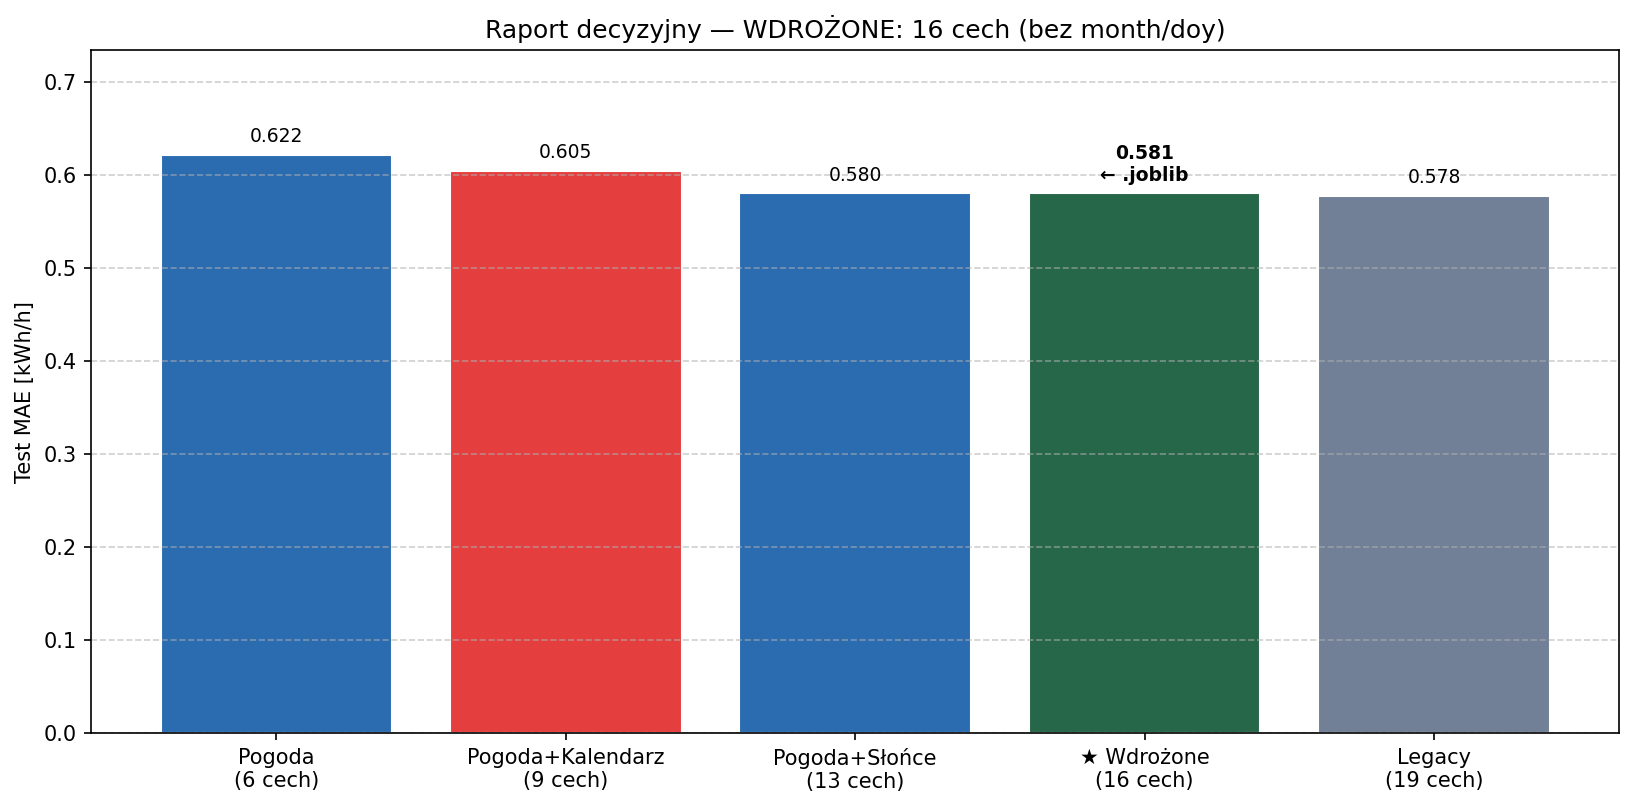

In [3]:
# Ablacja — z zapisanych wyników (bez live importu; stabilne na prezentacji)
import os, sys
from pathlib import Path
from IPython.display import Image, display, Markdown
import pandas as pd

def _project_root():
    """Działa gdy cwd = repo LUB notebooks/ (Cursor / Jupyter)."""
    from pathlib import Path
    here = Path.cwd().resolve()
    for root in (here, *here.parents):
        if (root / 'models' / 'pv_hourly_model.joblib').exists():
            return root
        if (root / 'reports' / 'figures' / 'hourly_algorithm_comparison.png').exists():
            return root
        db = root / 'data' / 'energy_model.db'
        if db.exists() and db.stat().st_size > 1_000_000:
            return root
        if (root / 'src' / 'models' / 'pv_hourly_predictor.py').exists():
            return root
    return here.parent if here.name == 'notebooks' else here

ROOT = _project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

csv_path = ROOT / 'data' / 'processed' / 'calendar_ablation_comparison.csv'
png_path = ROOT / 'reports' / 'figures' / 'calendar_ablation_comparison.png'

LABELS = {
    '2_Pogoda': 'Pogoda (6)',
    '3_Kalendarz': 'Pogoda+Kalendarz (9)',
    '3_Pogoda_Slonce': 'Pogoda+Słońce (13)',
    '3_Pogoda_Slonce_Reguly': '★ Wdrożone (16)',
    '4_Reguly': 'Legacy (19)',
}

df = pd.read_csv(csv_path)
df['Etykieta'] = df['Etap'].map(LABELS)
cols = [c for c in ['Etap', 'N_cech', 'Test_MAE', 'Test_R2', 'Wdrozony', 'Rekomendowany'] if c in df.columns]
print('=== Ablacja — dokładność (Test MAE) ===')
display(df[cols].round(3))

display(Markdown(
    '### Co jest w produkcji\n'
    '- **Wdrożone:** 16 cech (`HOURLY_FEATURE_COLUMNS_PRODUCTION`)\n'
    '- **Artefakt:** `models/pv_hourly_model.joblib`\n'
    '- **Bez** month/doy (Legacy 19 — nie używamy)'
))

if png_path.exists():
    display(Markdown(f'**Wykres:** `{png_path.relative_to(ROOT)}`'))
    display(Image(filename=str(png_path)))
else:
    print('⚠️ Brak PNG:', png_path)


### 📋 Werdykt

| Decyzja | Uzasadnienie |
|---------|--------------|
| **WYRZUCIĆ** `month`, `doy_*` z zestawu produkcyjnego | 16 cech (0.581) ≈ 19 cech (0.578); kalendarz nie bije ścieżki słońce |
| **ZOSTAWIĆ** cechy słoneczne | ΔMAE vs pogoda **−0.042** kWh/h |
| **ZOSTAWIĆ** śnieg / mgła | ΔMAE ≈ 0 globalnie; wartość w warunkach brzegowych |
| **WDROŻONE** 16 cech | expanding → **2026-08-10**: Test MAE **0.605** · `.joblib` (→ **2026-08-08**): **0.624** |

Wykres powyżej z `../docs/images/ml/calendar_ablation_comparison.png` (stan 2026-08-11).


---

## 5.2 Galeria wykresów (aktualizacja 2026-08-15)

Pipeline: [docs/02_ML_predykcja_PV.md](../docs/02_ML_predykcja_PV.md).  
**Tu powinny być m.in.:** porównanie z **gapami** (train/test + przeuczenie) oraz **wyniki modelu wdrożeniowego** (prognoza vs FoxESS, raw/hybryda).

Po regeneracji: `ablation_study.py` → `plot_*.py` → `compare_algorithms_hourly.py` → `plot_pv_timeseries_comparison.py`.

Wykresy operacyjne (`july_validation_plot` / `production_validation_plot`): closeouty **14.07→17.08**, actual = Δ `PVEnergyTotal` (timeseries).


**Raw / hybryda vs FoxESS (od 14.07)** · `reports/figures/production_validation_plot.png`

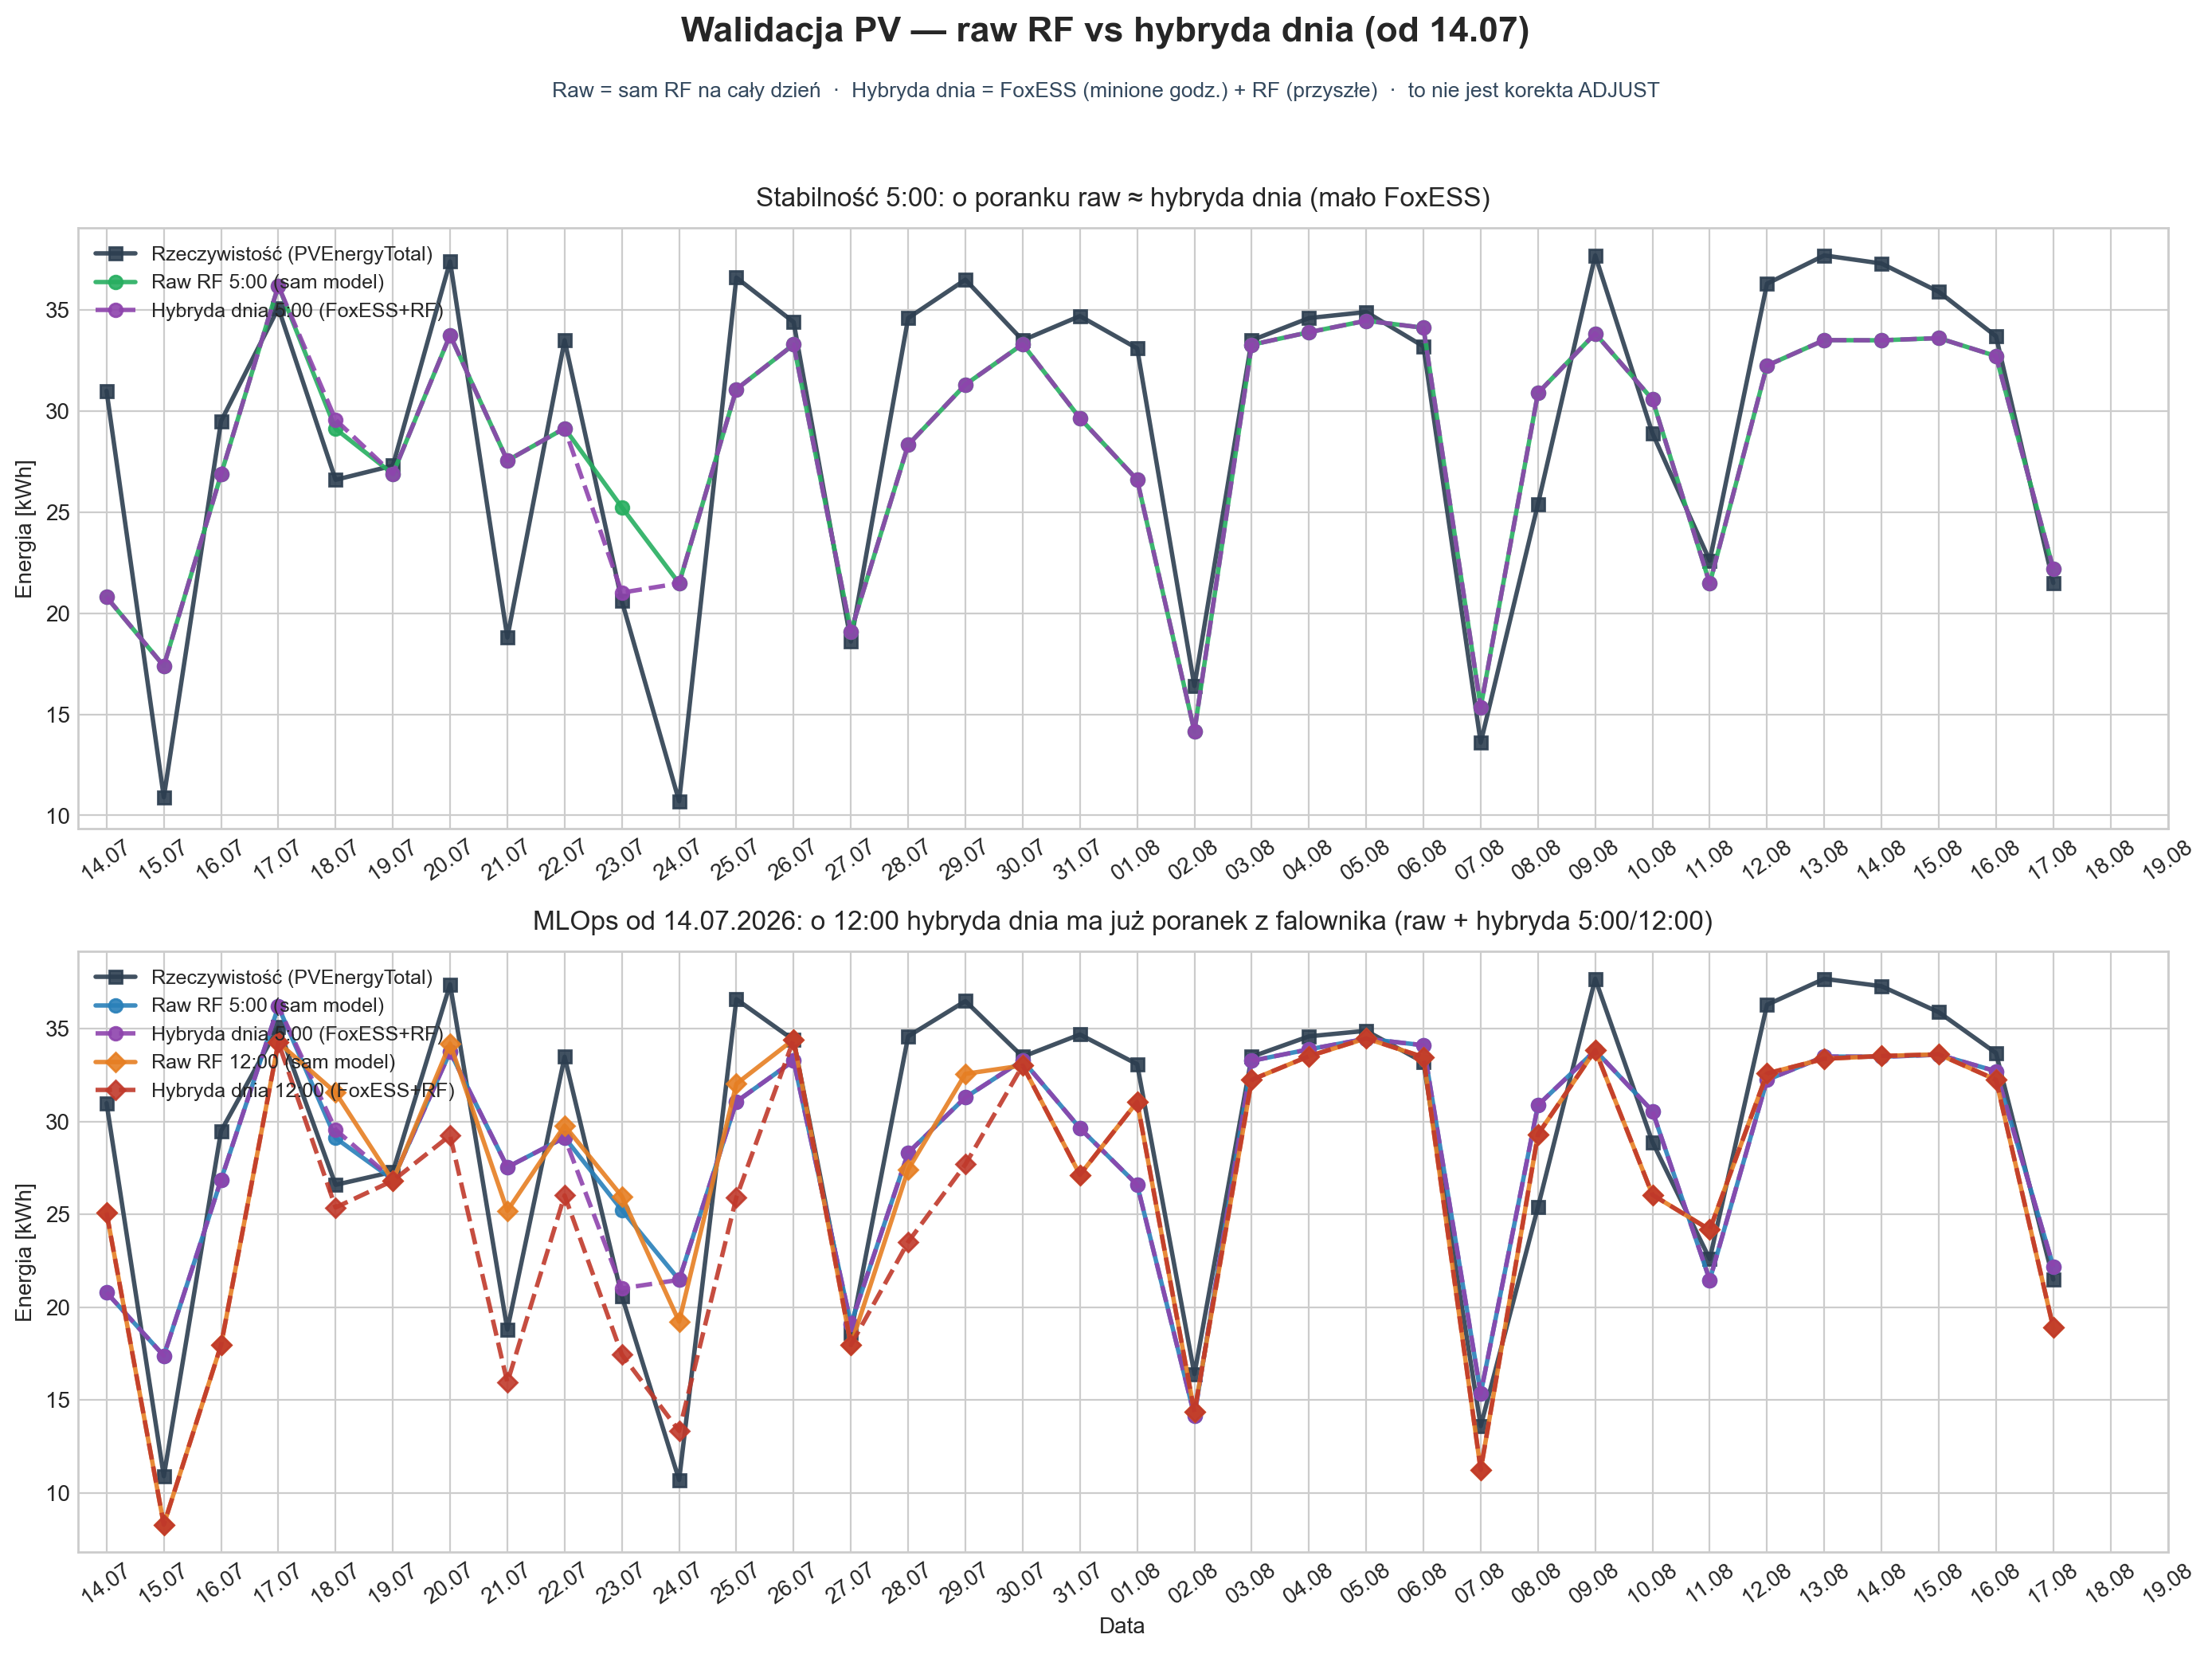

**Lipiec–sierpień — prognozy + słupki |APE| %** · `reports/figures/july_validation_plot.png`

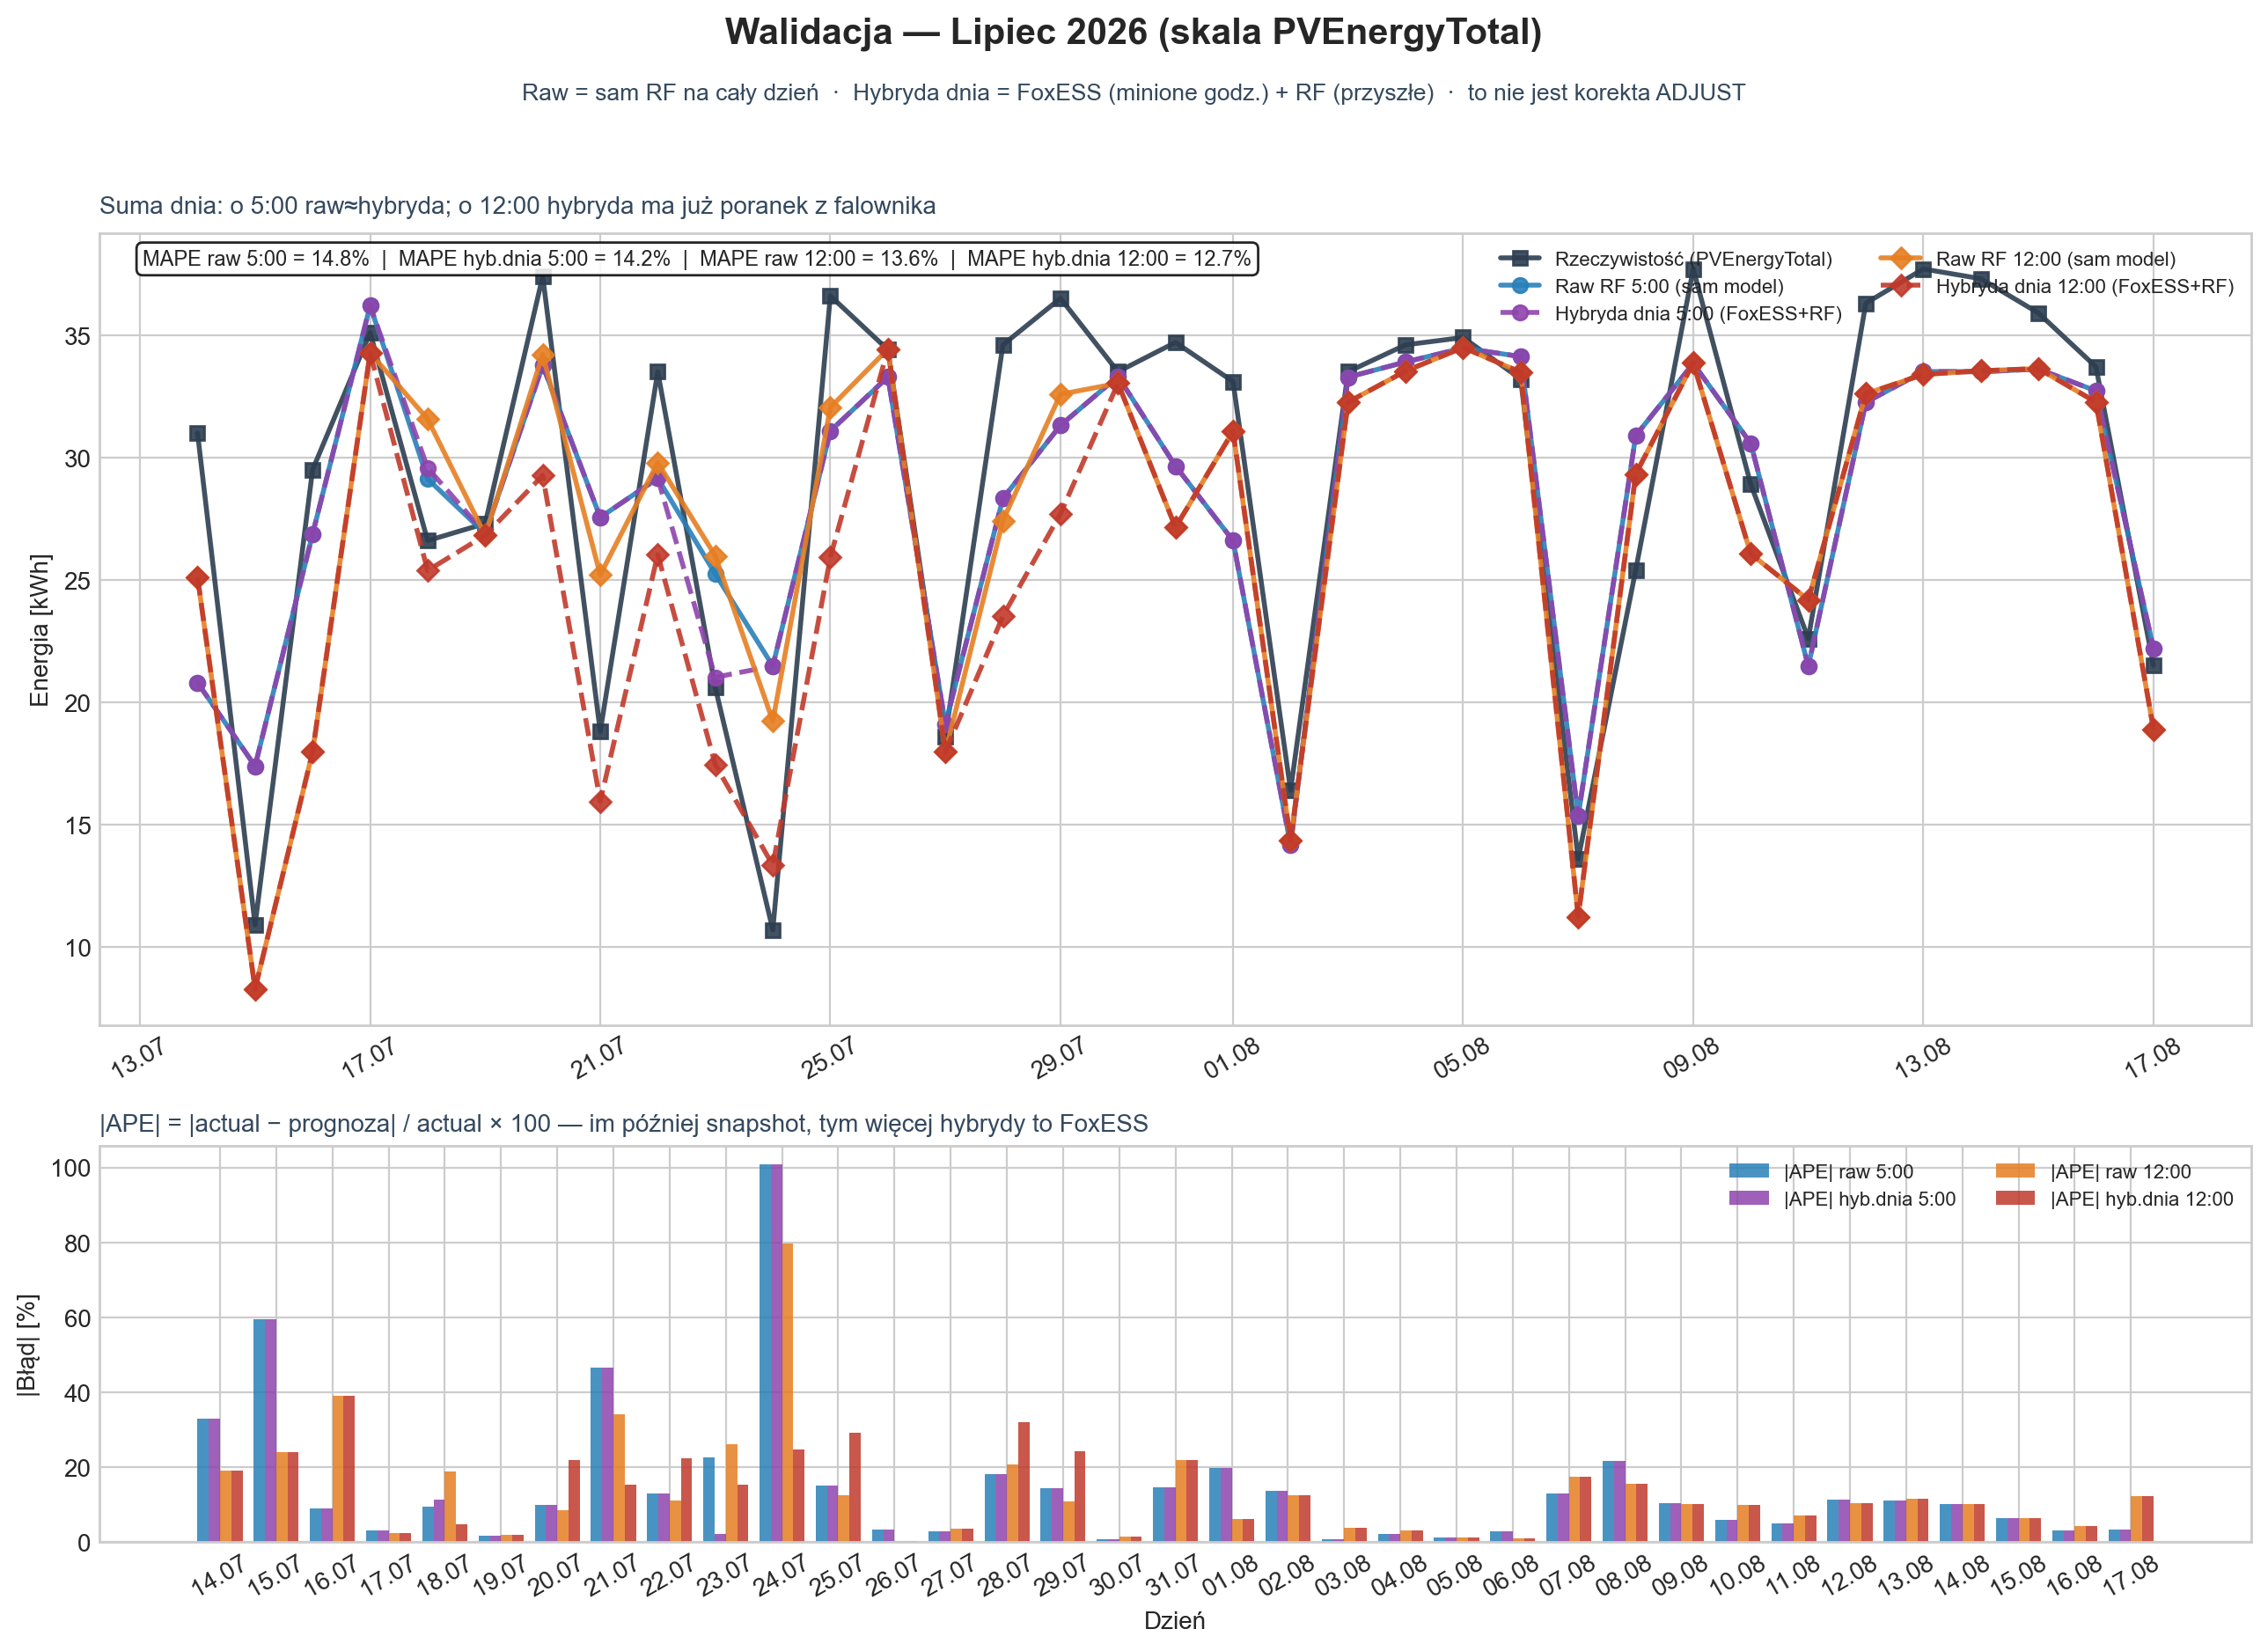

**Holdout godzinowy → dzień** · `reports/figures/production_validation.png`

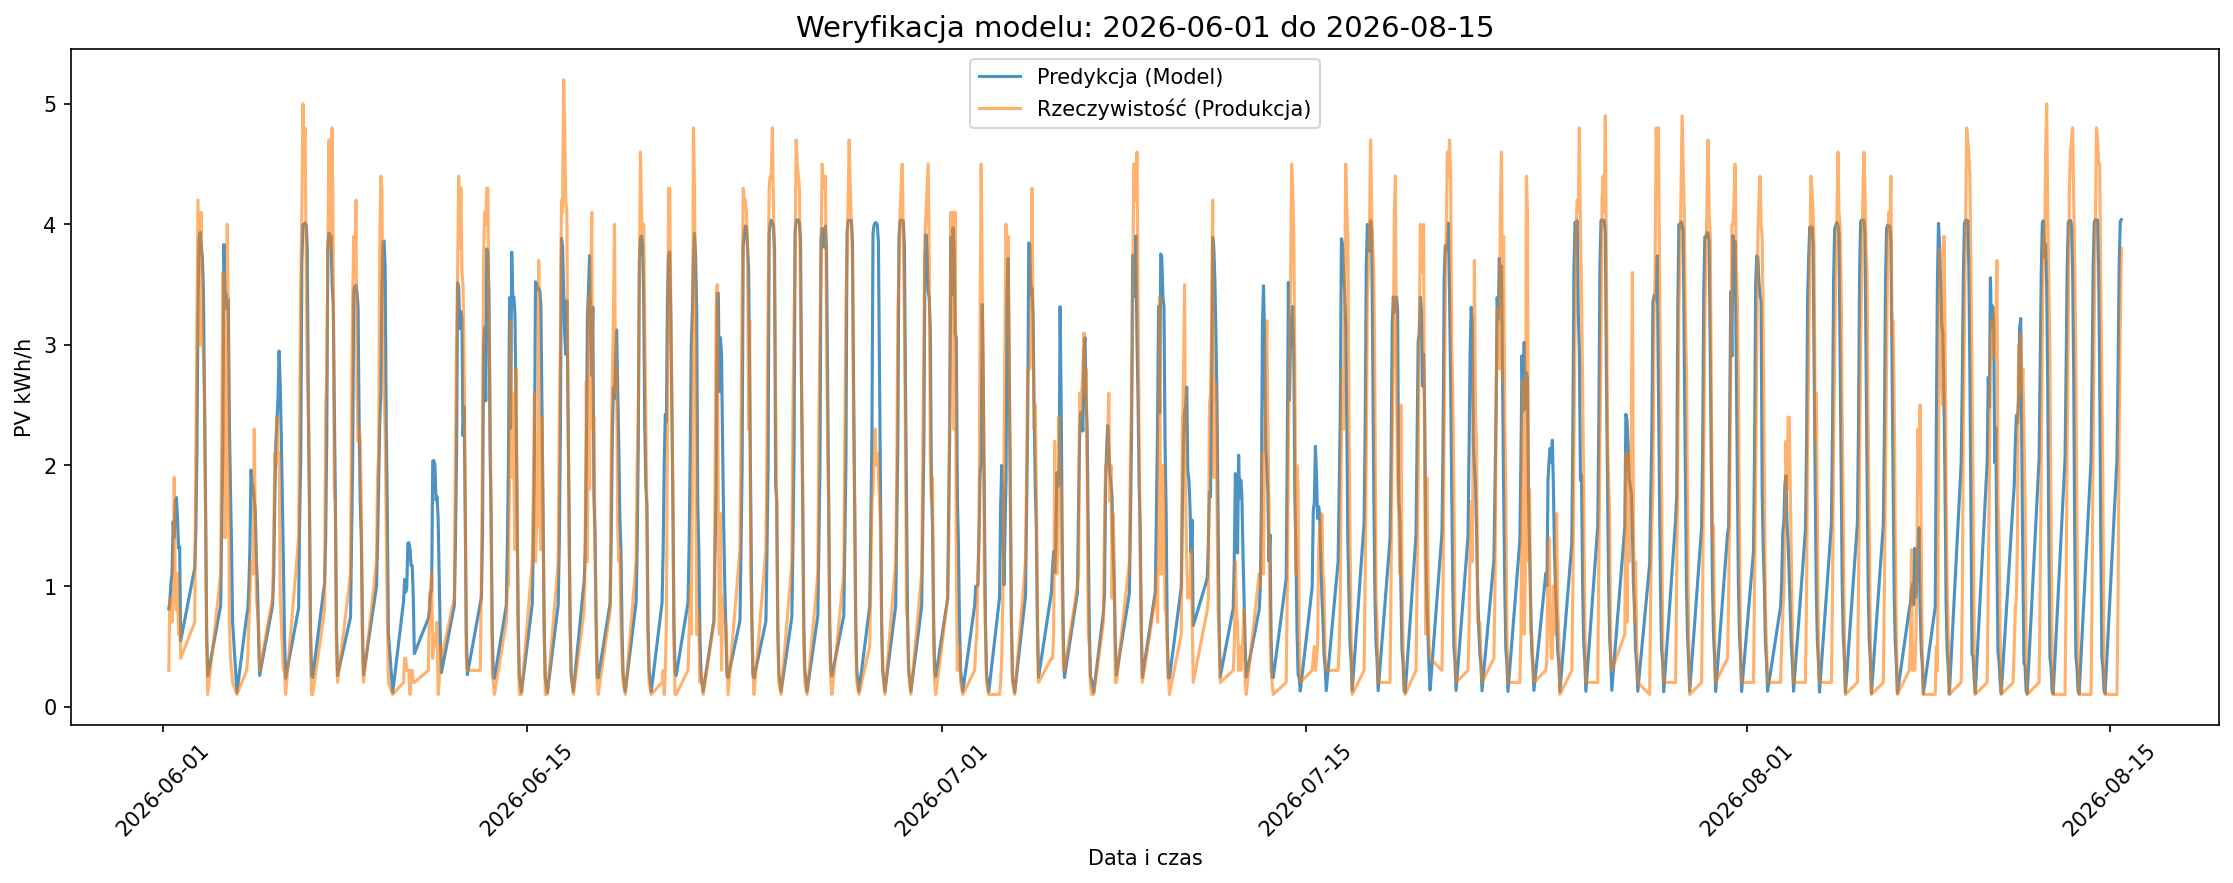

=== MAPE live (pod wykresami walidacji) ===


| okres | n_dni | MAPE_5:00_% | MAPE_12:00_% | MAPE_CS4_% |
| --- | --- | --- | --- | --- |
| Era dual 27.07–17.08 | 22 | 8.700 | 9.100 | 9.600 |
| Całość 14.07–17.08 | 35 | 14.800 | 13.600 | 9.600 |


=== Closeout 2026-08-08 — primary + shadow ===


| wariant | kWh | APE_% |
| --- | --- | --- |
| Actual (FoxESS app) | 25.400 | 0.000 |
| Primary RF 5:00 | 30.890 | 21.610 |
| Primary RF 12:00 | 29.320 | 15.430 |
| Shadow CS4 5:00 | 30.470 | 19.960 |
| Shadow CS4 12:00 | 28.440 | 11.970 |
| Shadow XGB+TS 5:00 | 31.640 | 24.570 |
| Shadow XGB+TS 12:00 | 27.520 | 8.350 |

Najlepszy wariant dnia: Shadow XGB+TS 12:00 (APE 8.3%)

=== Closeout 2026-08-09 — primary + shadow ===


| wariant | kWh | APE_% |
| --- | --- | --- |
| Actual (FoxESS app) | 37.700 | 0.000 |
| Primary RF 5:00 | 33.840 | 10.240 |
| Primary RF 12:00 | 33.860 | 10.190 |
| Shadow CS4 5:00 | 33.470 | 11.220 |
| Shadow CS4 12:00 | 33.340 | 11.560 |
| Shadow XGB+TS 5:00 | 35.260 | 6.470 |
| Shadow XGB+TS 12:00 | 35.110 | 6.870 |

Najlepszy wariant dnia: Shadow XGB+TS 5:00 (APE 6.5%)

=== Shadow vs primary RF 16 (rolling live) ===


| porównanie | shadow_lepiej | primary_lepiej |
| --- | --- | --- |
| Live daily 5:00 (27.07→17.08) | 6/22 | 16/22 |
| Live midday 12:00 | 4/22 | 18/22 |

CS4 daily wygrał: 06.08, 07.08, 08.08, 10.08, 16.08, 17.08


In [4]:
# 3 wykresy walidacji live (14.07→17.08) + kluczowe liczby pod spodem
from IPython.display import Image, display, Markdown
import pandas as pd

VALIDATION_FIGS = [
    ('Raw / hybryda vs FoxESS (od 14.07)', 'production_validation_plot.png'),
    ('Lipiec–sierpień — prognozy + słupki |APE| %', 'july_validation_plot.png'),
    ('Holdout godzinowy → dzień', 'production_validation.png'),
]
for title, name in VALIDATION_FIGS:
    p = _fig_path(name)
    display(Markdown(f'**{title}** · `{p.relative_to(ROOT)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print('⚠️ Brak:', p)

DATA = ROOT / 'data' / 'processed'
val = pd.read_csv(DATA / 'forecasts' / 'forecast_validation.csv')
val['target_day'] = pd.to_datetime(val['target_day'])
sub = val.dropna(subset=['actual_pv_report', 'predicted_daily_raw']).copy()
sub = sub[sub['actual_pv_report'] > 0.5]
sub['ape_daily_%'] = (sub['predicted_daily_raw'] - sub['actual_pv_report']).abs() / sub['actual_pv_report'] * 100
sub['ape_midday_%'] = (sub['predicted_midday_raw'] - sub['actual_pv_report']).abs() / sub['actual_pv_report'] * 100
if 'predicted_daily_cs4' in sub.columns:
    sub['ape_cs4_%'] = (sub['predicted_daily_cs4'] - sub['actual_pv_report']).abs() / sub['actual_pv_report'] * 100

era = sub[sub['target_day'] >= '2026-07-27']
all_ = sub[sub['target_day'] >= '2026-07-14']
end_label = sub['target_day'].max().strftime('%d.%m')

def show_table(df):
    d = df.copy()
    for c in d.columns:
        if pd.api.types.is_float_dtype(d[c]):
            d[c] = d[c].map(lambda x: f'{x:.3f}' if pd.notna(x) else '')
    cols = [str(c) for c in d.columns]
    lines = ['| ' + ' | '.join(cols) + ' |', '| ' + ' | '.join(['---'] * len(cols)) + ' |']
    for _, row in d.iterrows():
        lines.append('| ' + ' | '.join(str(v) for v in row.tolist()) + ' |')
    display(Markdown('\n'.join(lines)))

print('=== MAPE live (pod wykresami walidacji) ===')
show_table(pd.DataFrame([
    {'okres': f'Era dual 27.07–{end_label}', 'n_dni': len(era),
     'MAPE_5:00_%': era['ape_daily_%'].mean(), 'MAPE_12:00_%': era['ape_midday_%'].mean(),
     'MAPE_CS4_%': era['ape_cs4_%'].mean() if 'ape_cs4_%' in era.columns else None},
    {'okres': f'Całość 14.07–{end_label}', 'n_dni': len(all_),
     'MAPE_5:00_%': all_['ape_daily_%'].mean(), 'MAPE_12:00_%': all_['ape_midday_%'].mean(),
     'MAPE_CS4_%': all_['ape_cs4_%'].mean() if 'ape_cs4_%' in all_.columns else None},
]).round(1))

CASE_DAYS = ['2026-08-08', '2026-08-09']

def _shadow_from_history(day, labels):
    hist_path = DATA / 'forecasts' / 'forecast_history.csv'
    if not hist_path.exists():
        return []
    hist = pd.read_csv(hist_path)
    h = hist[hist['target_day'].astype(str) == day]
    out = []
    for name, run_label in labels:
        snap = h[h['run_label'] == run_label].sort_values('run_at').tail(1)
        if not snap.empty:
            out.append((name, float(snap.iloc[0]['predicted_kwh'])))
    return out

for CLOSEOUT_DAY in CASE_DAYS:
    if CLOSEOUT_DAY not in sub['target_day'].dt.strftime('%Y-%m-%d').values:
        continue
    row = sub[sub['target_day'] == CLOSEOUT_DAY].iloc[0]
    act = float(row['actual_pv_report'])
    closeout_rows = [
        ('Actual (FoxESS app)', act),
        ('Primary RF 5:00', row['predicted_daily_raw']),
        ('Primary RF 12:00', row['predicted_midday_raw']),
        ('Shadow CS4 5:00', row.get('predicted_daily_cs4')),
        ('Shadow CS4 12:00', row.get('predicted_midday_cs4')),
    ]
    closeout_rows += _shadow_from_history(CLOSEOUT_DAY, [
        ('Shadow XGB+TS 5:00', 'daily_xgb_ts'),
        ('Shadow XGB+TS 12:00', 'midday_xgb_ts'),
    ])
    today_tbl = pd.DataFrame([
        {'wariant': n, 'kWh': v, 'APE_%': 0.0 if n.startswith('Actual') else abs(v - act) / act * 100}
        for n, v in closeout_rows if pd.notna(v)
    ]).round(2)
    print(f'\n=== Closeout {CLOSEOUT_DAY} — primary + shadow ===')
    show_table(today_tbl)
    best = today_tbl.loc[today_tbl['wariant'] != 'Actual (FoxESS app)', 'APE_%'].idxmin()
    print(f'Najlepszy wariant dnia: {today_tbl.loc[best, "wariant"]} (APE {today_tbl.loc[best, "APE_%"]:.1f}%)')

dual = sub[sub['target_day'] >= '2026-07-27'].dropna(subset=['predicted_daily_cs4', 'predicted_daily_raw'])
dual['err16'] = (dual['predicted_daily_raw'] - dual['actual_pv_report']).abs()
dual['err_cs4'] = (dual['predicted_daily_cs4'] - dual['actual_pv_report']).abs()
n_dual = len(dual)
n_cs4 = int((dual['err_cs4'] < dual['err16']).sum())
mid = dual.dropna(subset=['predicted_midday_cs4', 'predicted_midday_raw'])
n_mid = int(((mid['predicted_midday_cs4'] - mid['actual_pv_report']).abs() < (mid['predicted_midday_raw'] - mid['actual_pv_report']).abs()).sum())

print('\n=== Shadow vs primary RF 16 (rolling live) ===')
show_table(pd.DataFrame([
    {'porównanie': f'Live daily 5:00 (27.07→{end_label})', 'shadow_lepiej': f'{n_cs4}/{n_dual}', 'primary_lepiej': f'{n_dual-n_cs4}/{n_dual}'},
    {'porównanie': 'Live midday 12:00', 'shadow_lepiej': f'{n_mid}/{len(mid)}', 'primary_lepiej': f'{len(mid)-n_mid}/{len(mid)}'},
]))
if n_cs4:
    win_days = dual.loc[dual['err_cs4'] < dual['err16'], 'target_day'].dt.strftime('%d.%m').tolist()
    print('CS4 daily wygrał:', ', '.join(win_days))


**Podział 80/20**

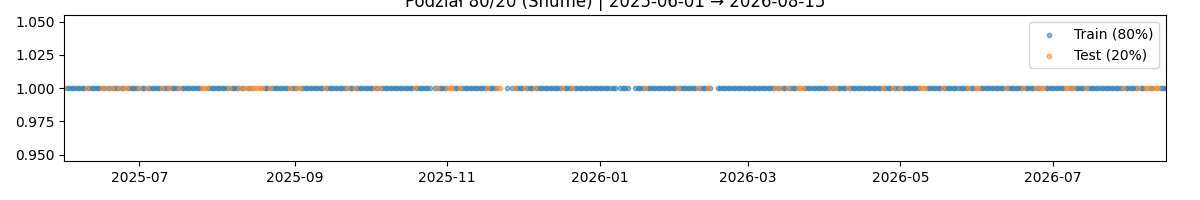

**Ablacja MAE**

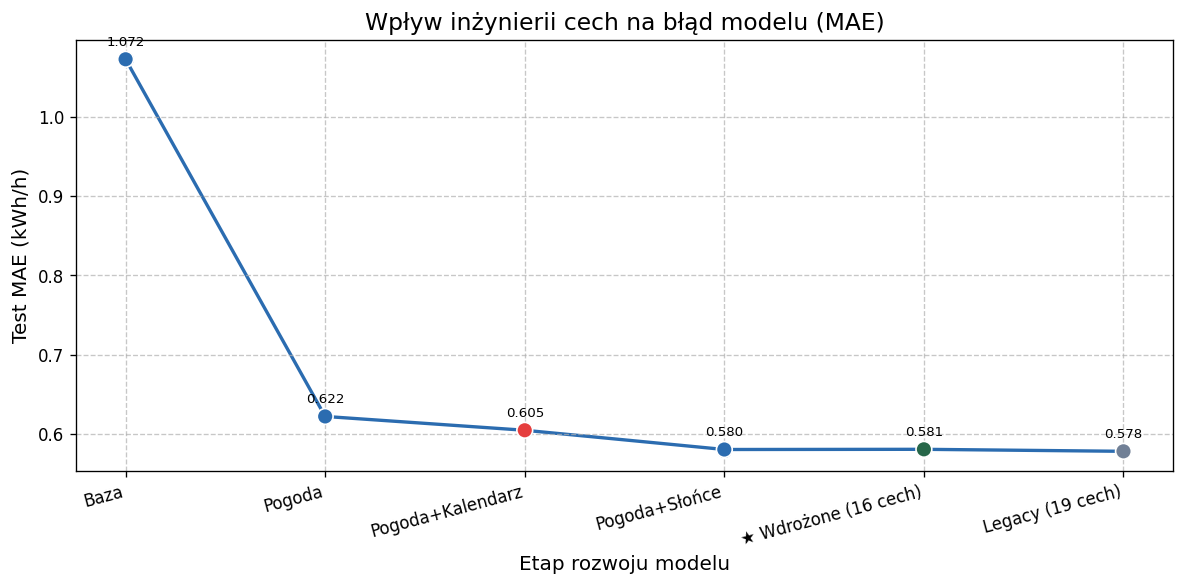

**Raport decyzyjny — wybór cech**

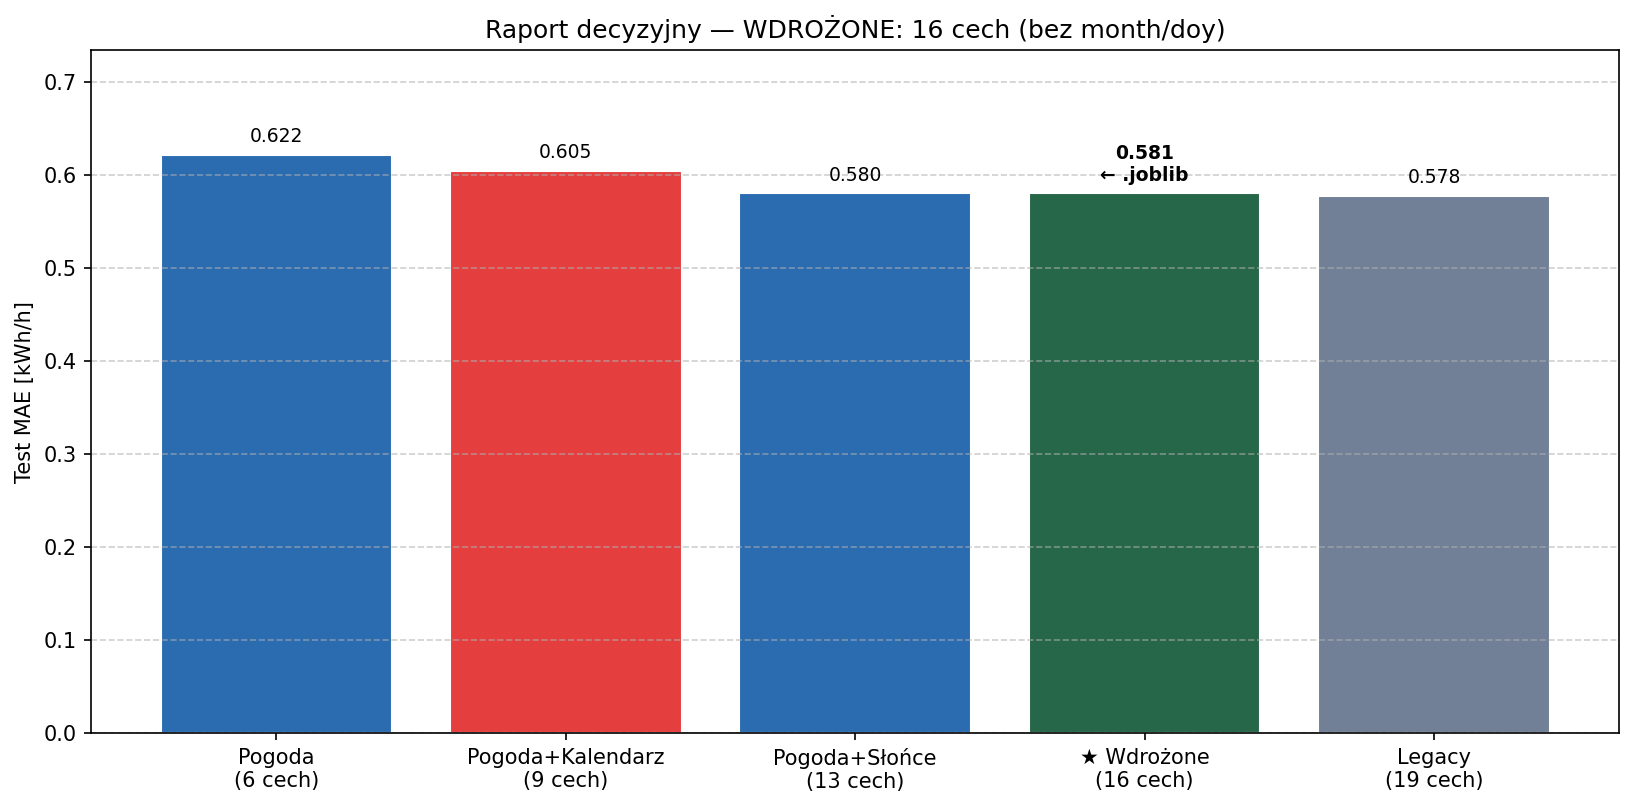

**Krzywe uczenia — ablacja**

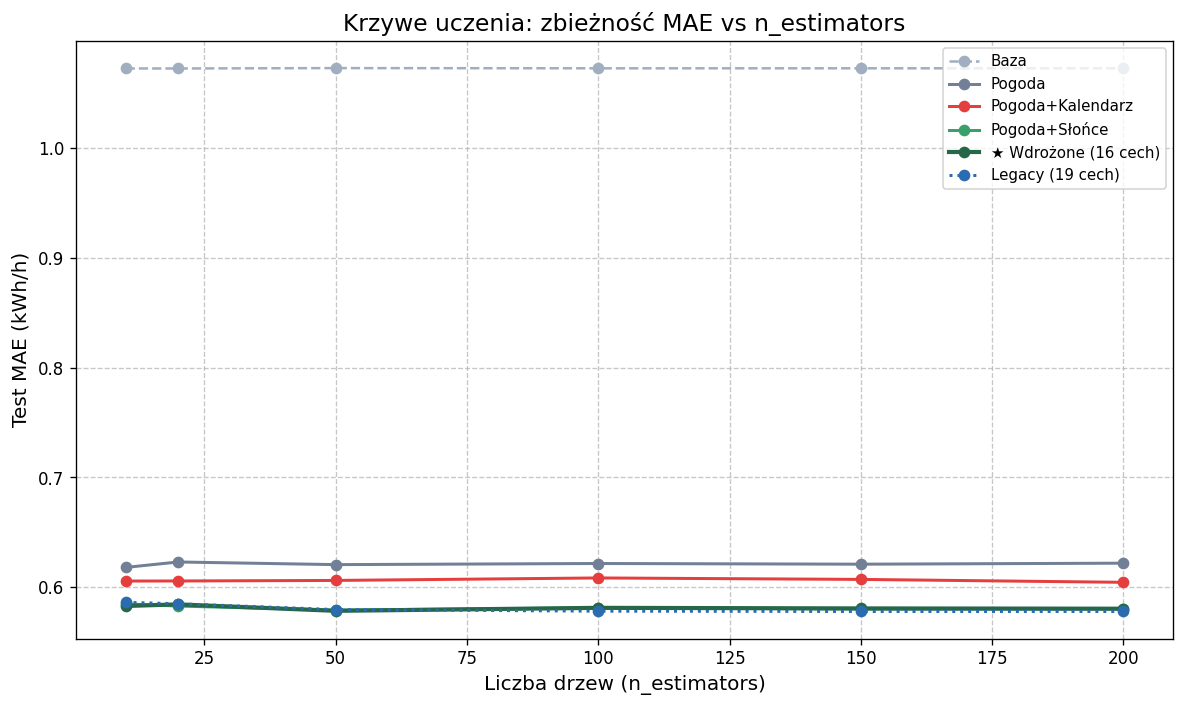

**★ Gap / przeuczenie (train vs test + gap)**

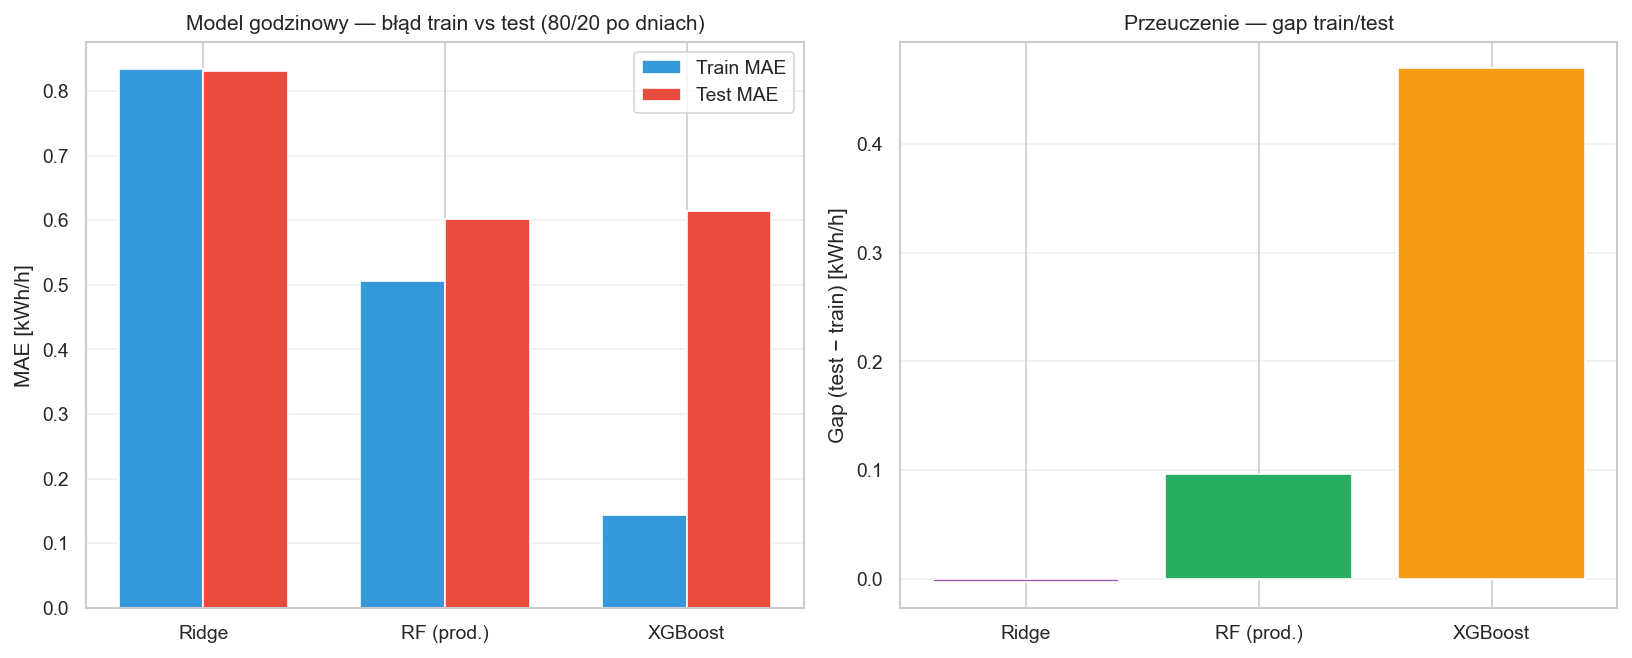

**MAE / RMSE train vs test**

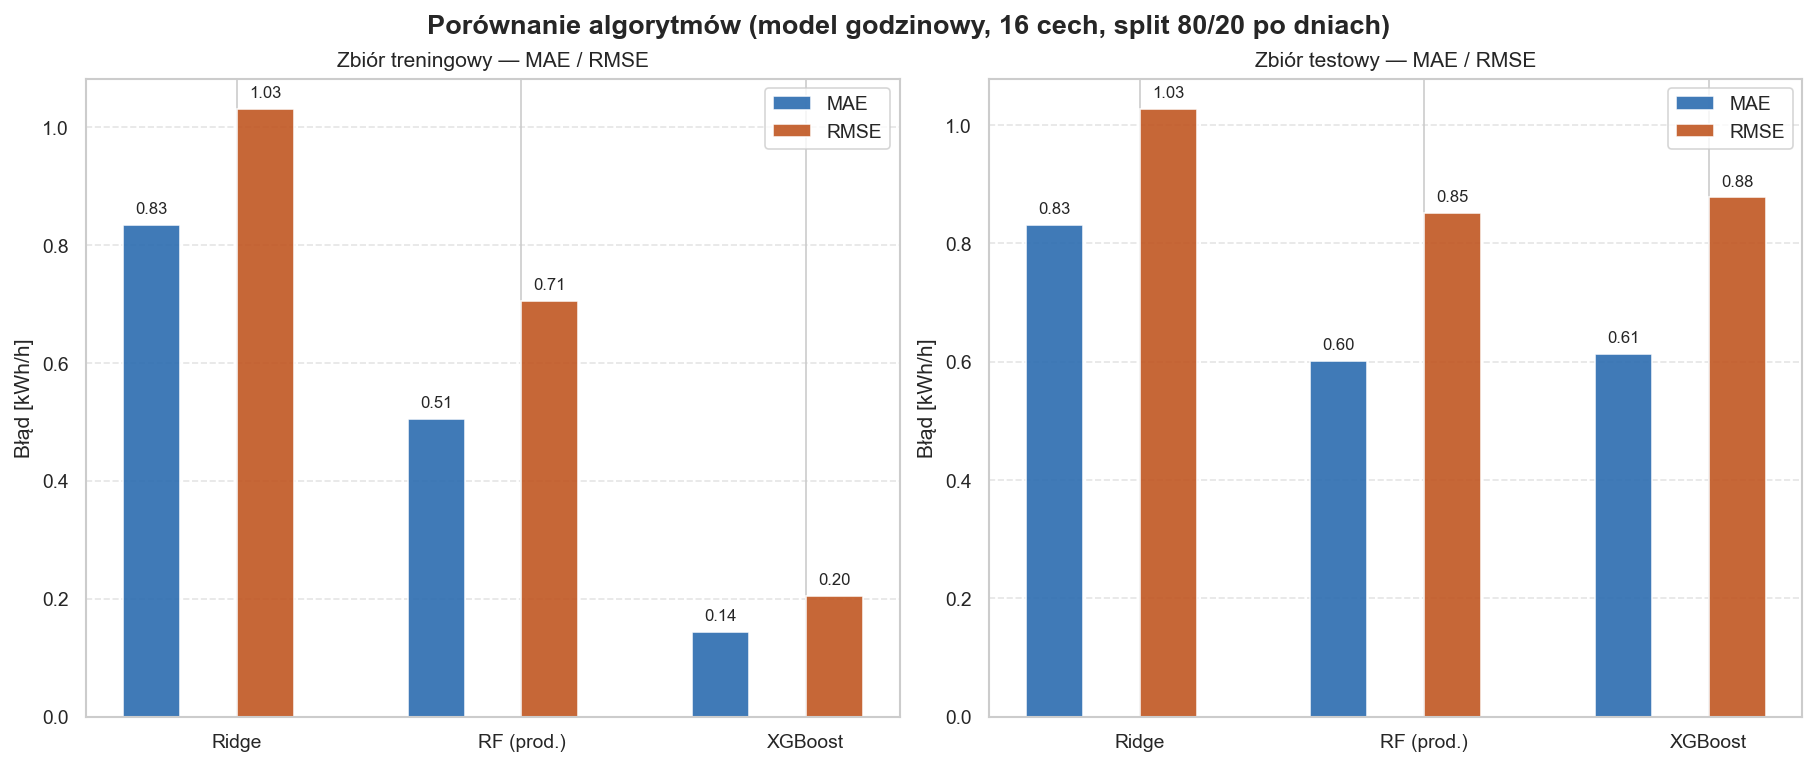

**R² train vs test**

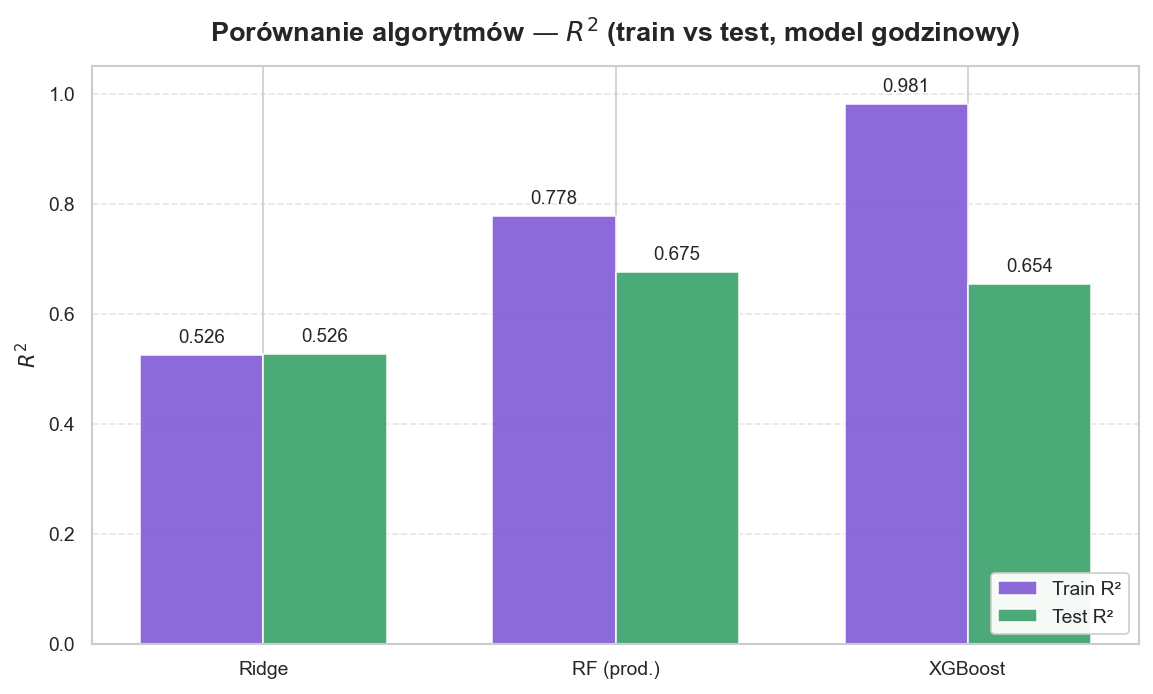

**Krzywe uczenia algorytmów**

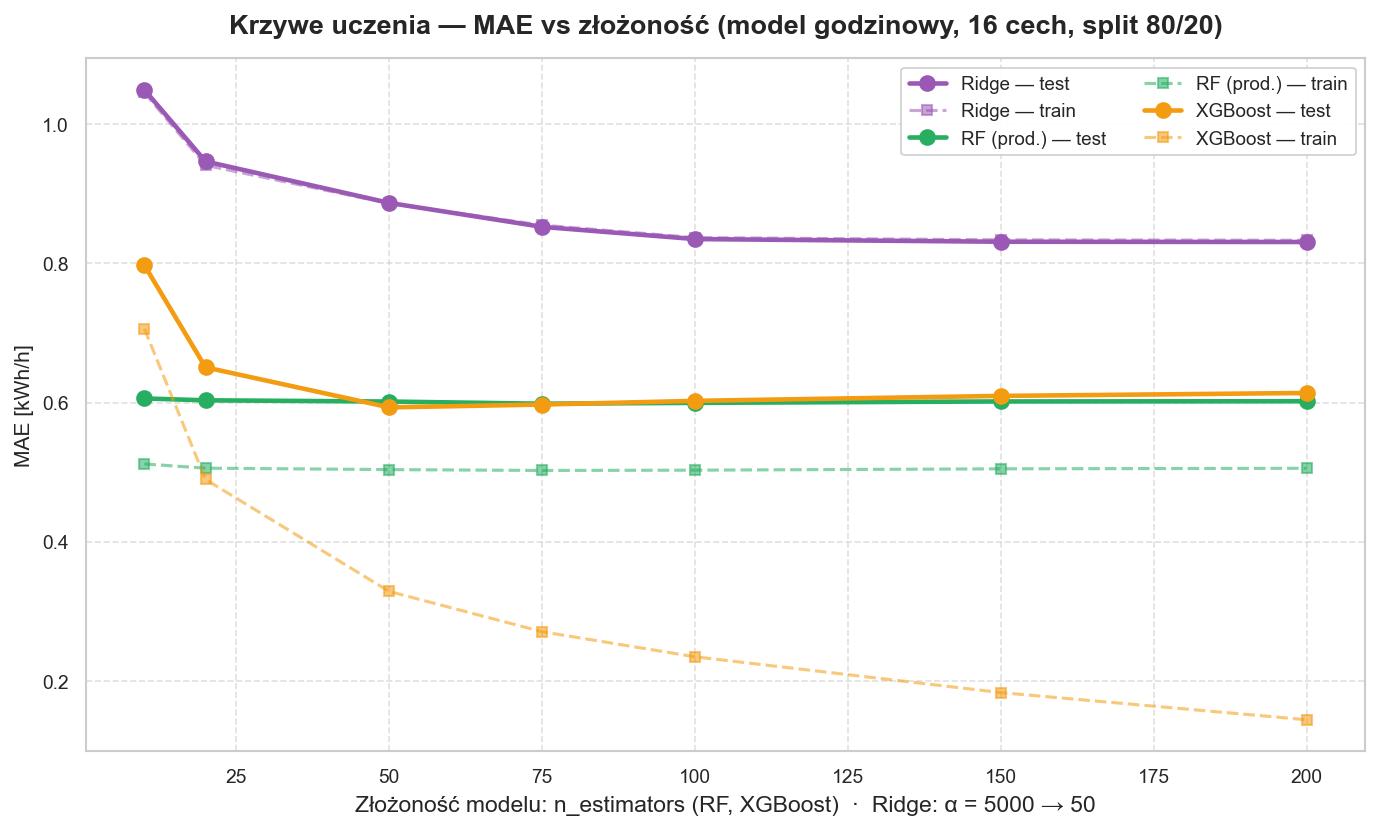

**Krzywe uczenia — model wdrożeniowy**

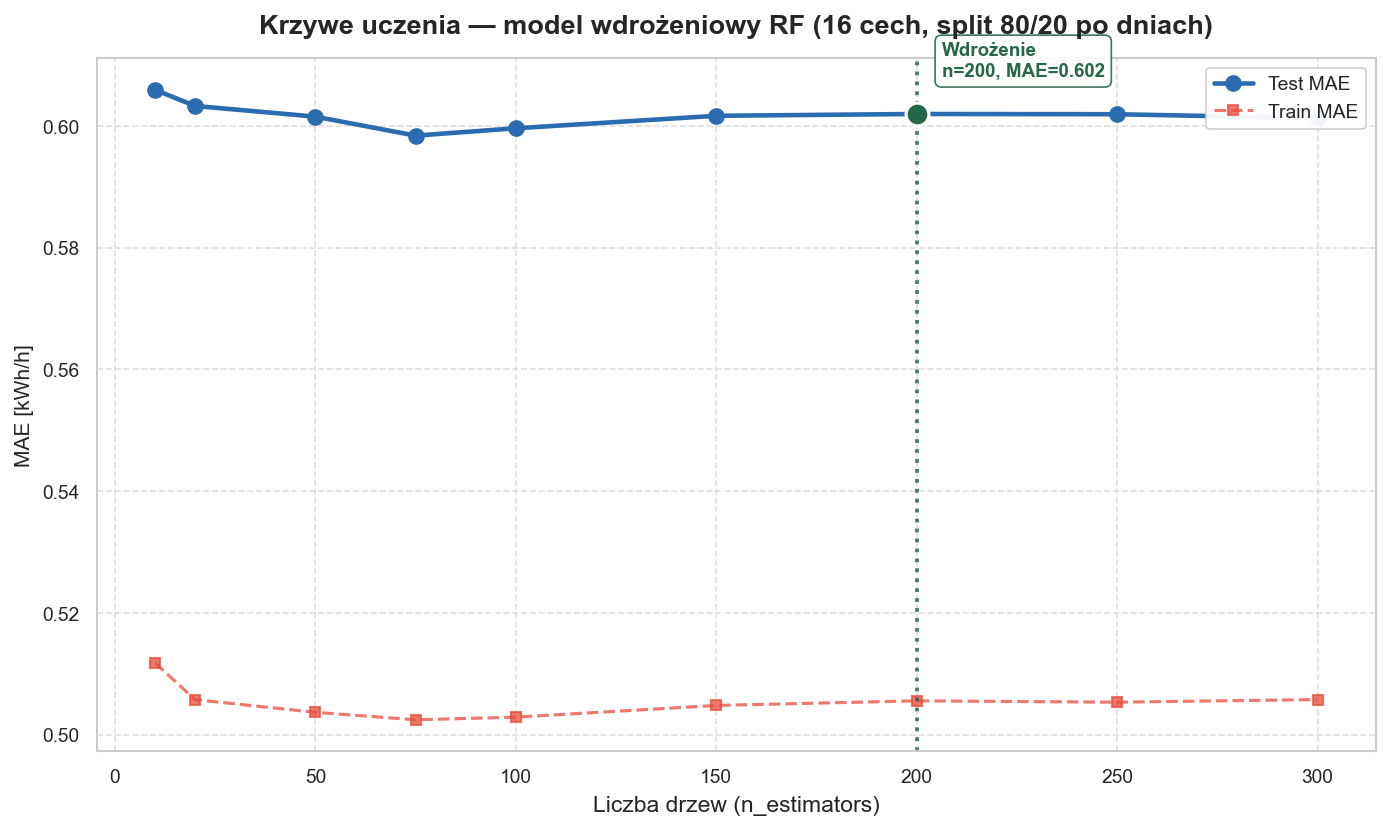

**Scatter akademicki**

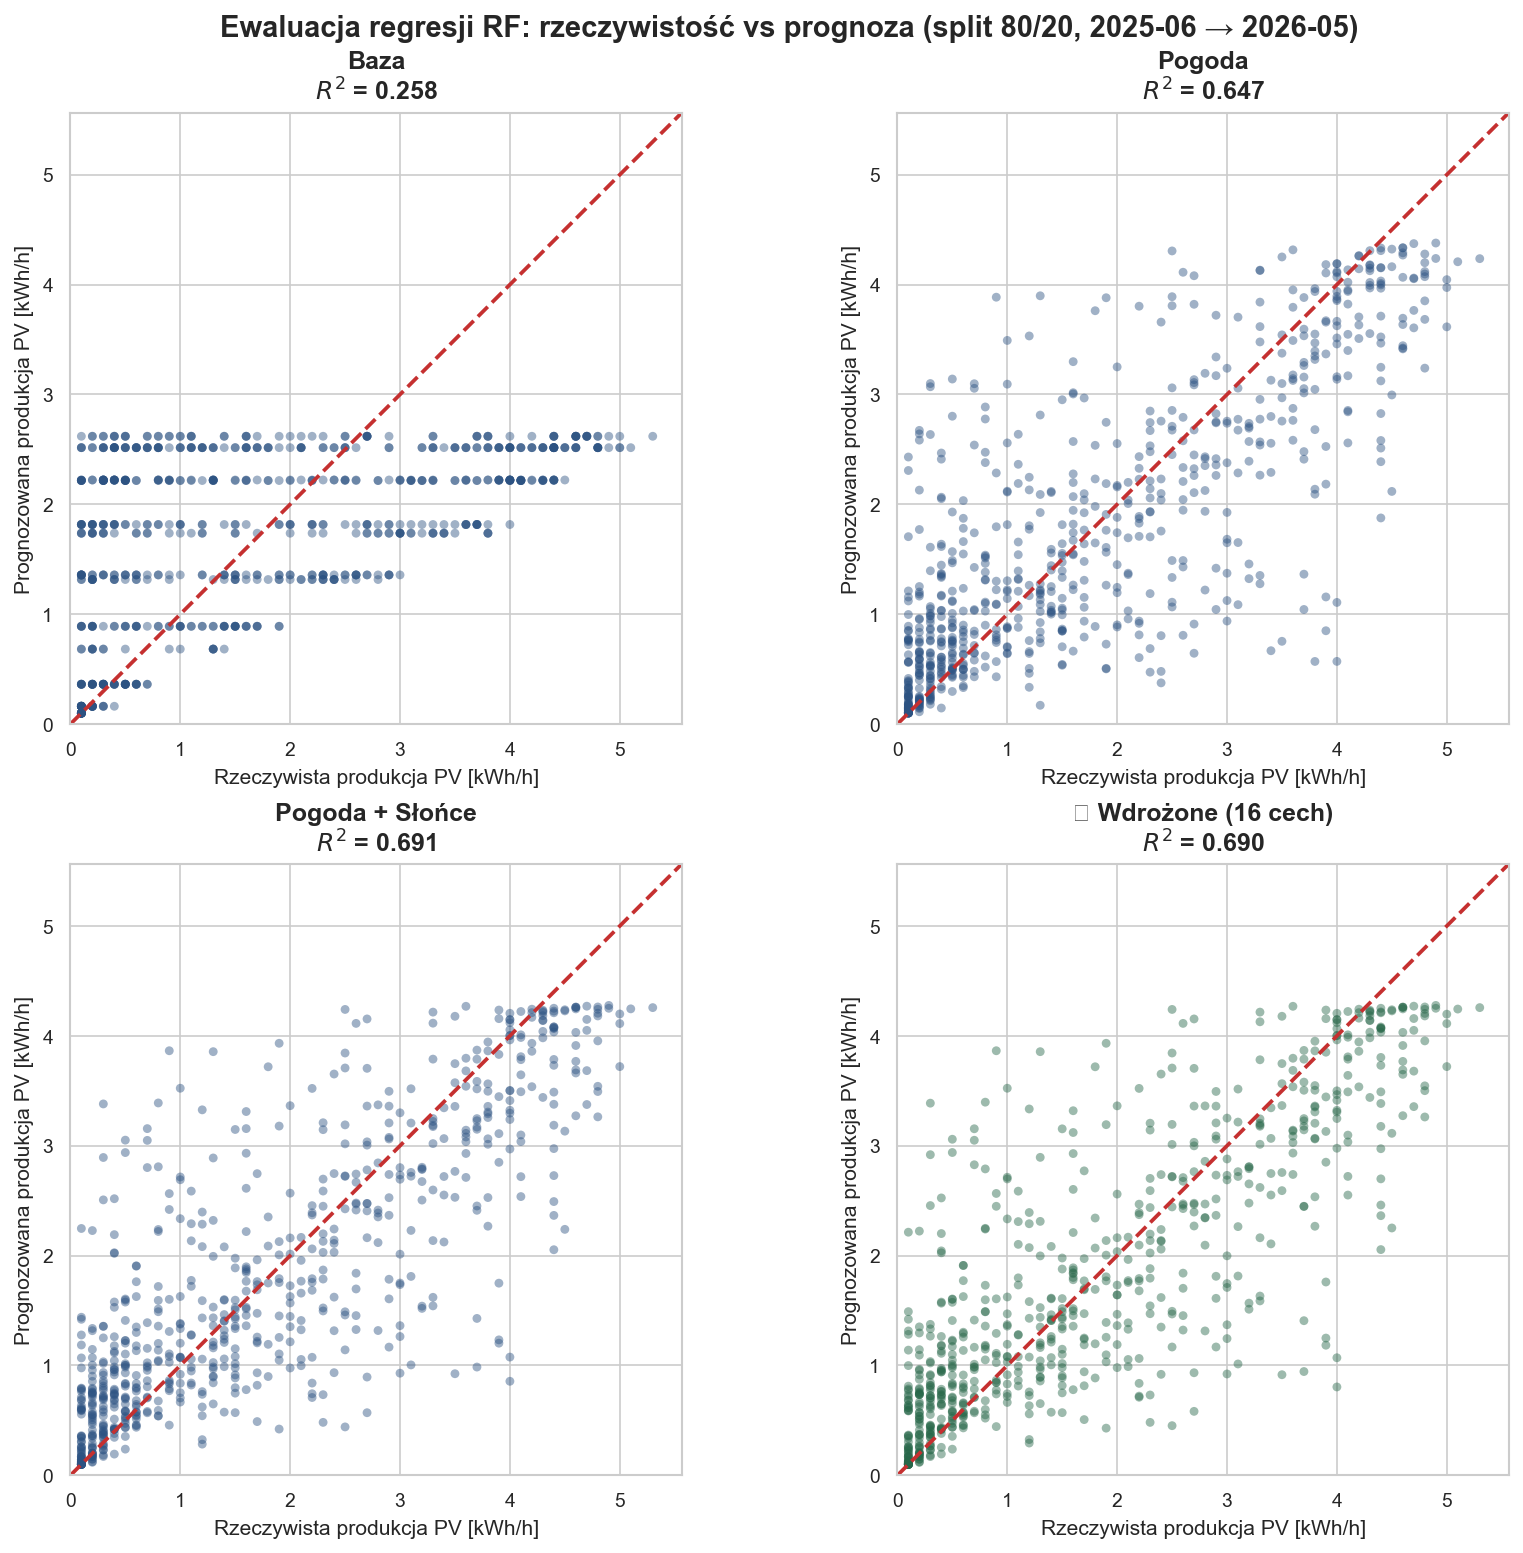

**Spadek MAE / RMSE**

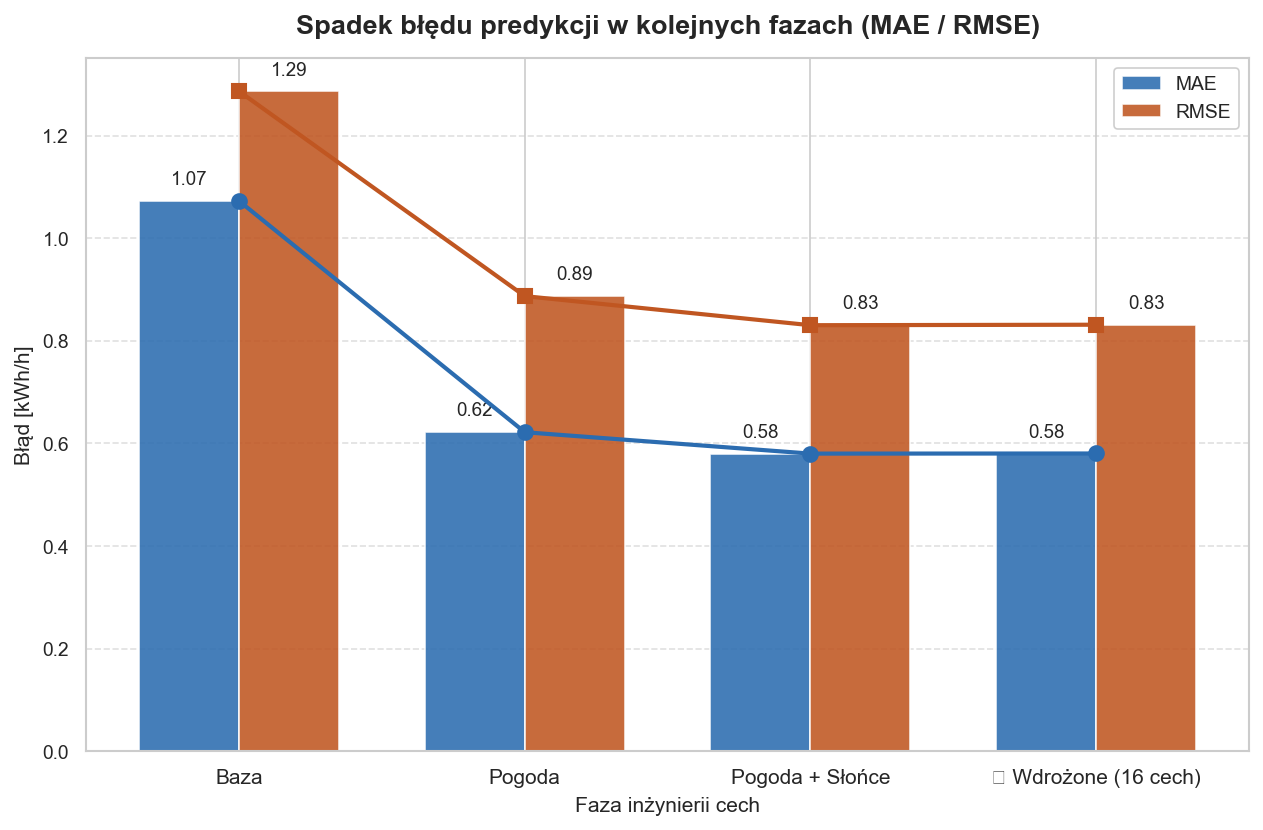

**★ Holdout — porównanie modeli**

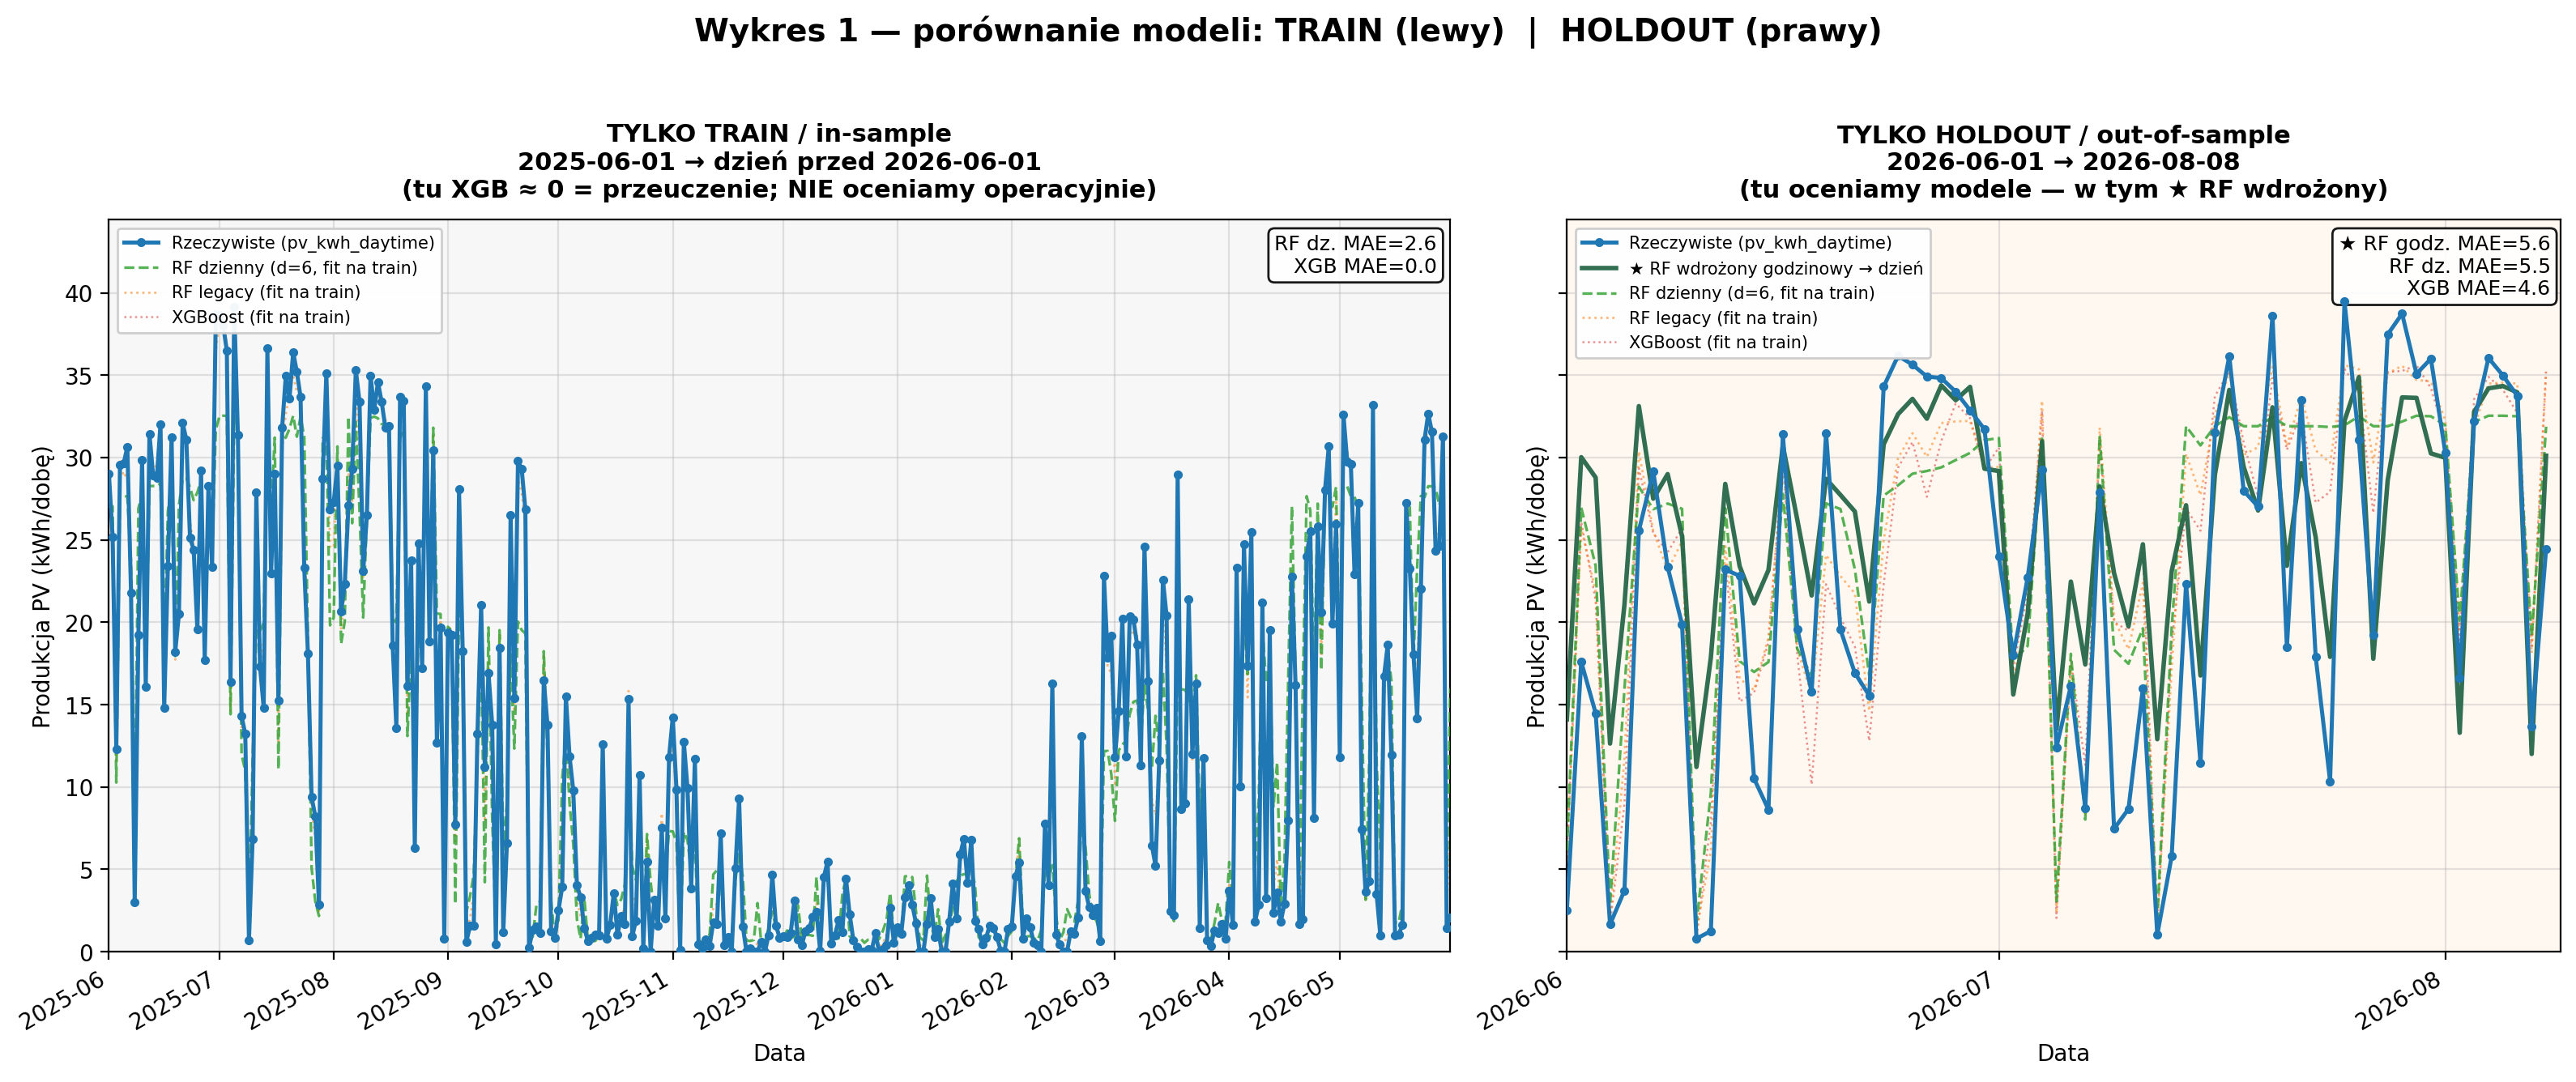

**★ Model wdrożeniowy ★ RF vs rzeczywistość**

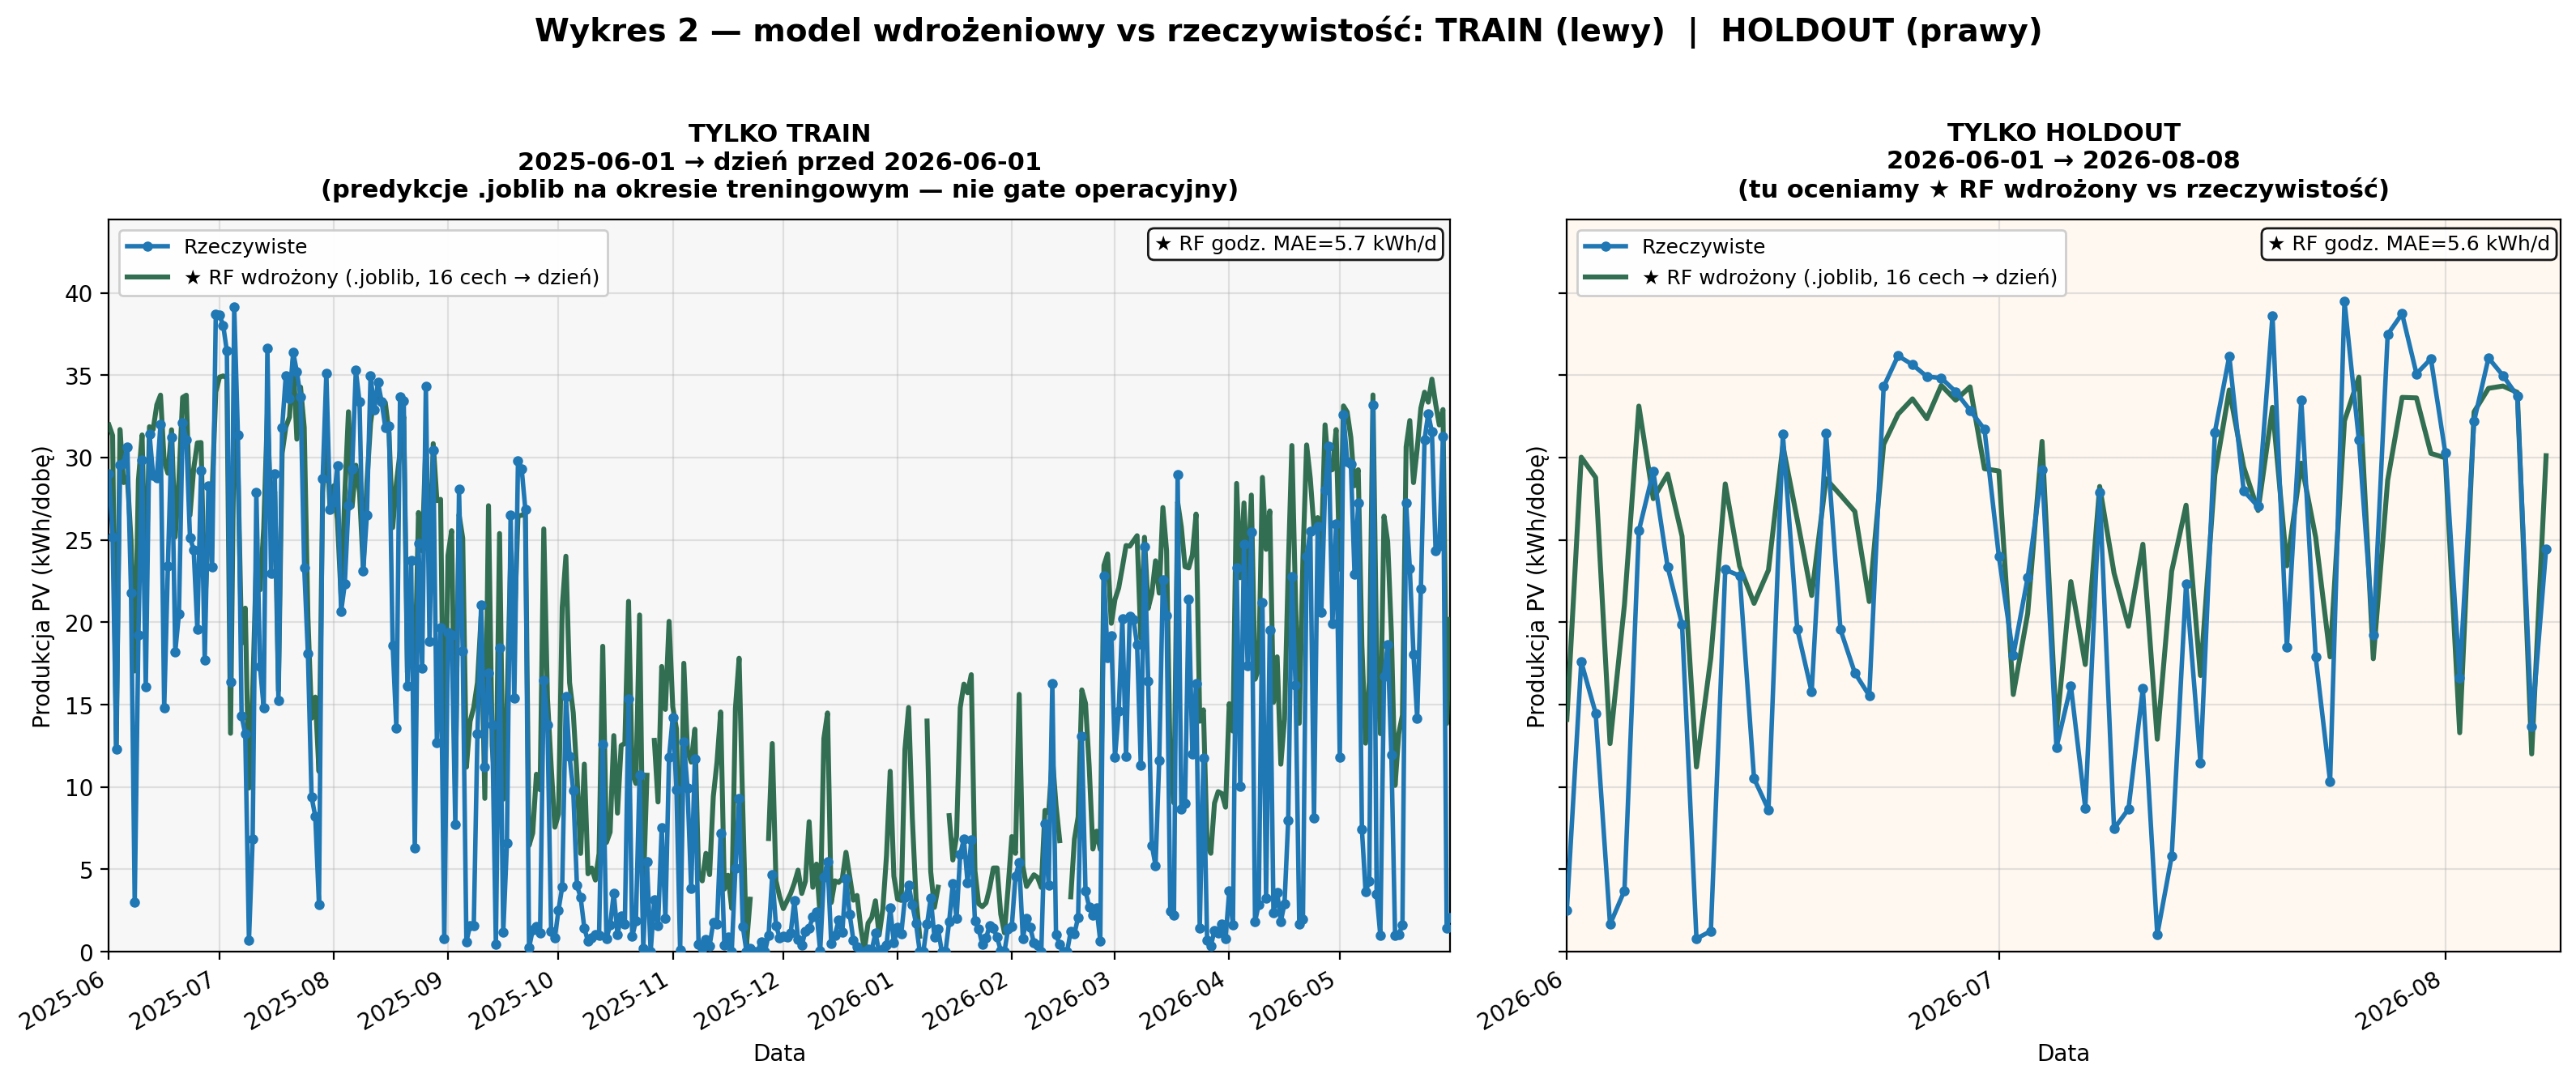

✓ Galeria OK — 13 wykresów


In [5]:
from IPython.display import Image, display, Markdown
from pathlib import Path
import os

def _project_root():
    """Działa gdy cwd = repo LUB notebooks/ (Cursor / Jupyter)."""
    from pathlib import Path
    here = Path.cwd().resolve()
    for root in (here, *here.parents):
        if (root / 'models' / 'pv_hourly_model.joblib').exists():
            return root
        if (root / 'reports' / 'figures' / 'hourly_algorithm_comparison.png').exists():
            return root
        db = root / 'data' / 'energy_model.db'
        if db.exists() and db.stat().st_size > 1_000_000:
            return root
        if (root / 'src' / 'models' / 'pv_hourly_predictor.py').exists():
            return root
    return here.parent if here.name == 'notebooks' else here

ROOT = _project_root()
os.chdir(ROOT)
FIGS = ROOT / 'reports' / 'figures'

GALLERY = [
    ('Podział 80/20', 'data_split_viz.png'),
    ('Ablacja MAE', 'ablation_chart.png'),
    ('Raport decyzyjny — wybór cech', 'calendar_ablation_comparison.png'),
    ('Krzywe uczenia — ablacja', 'learning_curves.png'),
    ('★ Gap / przeuczenie (train vs test + gap)', 'hourly_algorithm_comparison.png'),
    ('MAE / RMSE train vs test', 'hourly_algorithm_errors_mae_rmse.png'),
    ('R² train vs test', 'hourly_algorithm_r2.png'),
    ('Krzywe uczenia algorytmów', 'hourly_algorithm_learning_curves.png'),
    ('Krzywe uczenia — model wdrożeniowy', 'production_learning_curves.png'),
    ('Scatter akademicki', 'academic_scatter_actual_vs_pred.png'),
    ('Spadek MAE / RMSE', 'academic_errors_mae_rmse.png'),
    ('★ Holdout — porównanie modeli', 'prediction_vs_actual_train_vs_holdout.png'),
    ('★ Model wdrożeniowy ★ RF vs rzeczywistość', 'prediction_vs_actual_deployed_train_vs_holdout.png'),
    # Walidacja live (raw/hybryda/lipiec) — tylko w komórce powyżej, bez dublowania
]

missing = []
for title, name in GALLERY:
    path = FIGS / name
    if not path.exists():
        missing.append(name)
        print('⚠️ Brak:', path)
        continue
    display(Markdown(f'**{title}**'))
    display(Image(filename=str(path)))

if missing:
    print('Brak:', ', '.join(missing))
else:
    print(f'✓ Galeria OK — {len(GALLERY)} wykresów')


In [6]:
# Podsumowanie pod wykresem lipca: pogoda + kiedy hybryda pomaga/szkodzi
from IPython.display import Markdown, display
from pathlib import Path
import sys

root = _project_root() if "_project_root" in dir() else Path.cwd().resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

summary_path = root / "reports" / "figures" / "july_validation_summary.md"
if not summary_path.exists():
    from scripts.plots.plot_july_validation import (
        load_july_validation,
        build_july_error_summary,
        DEFAULT_VALIDATION,
    )
    df_july = load_july_validation(DEFAULT_VALIDATION)
    summary_path.write_text(
        build_july_error_summary(df_july, db_path=root / "data" / "energy_model.db"),
        encoding="utf-8",
    )
    print("✓ Wygenerowano", summary_path)

display(Markdown(summary_path.read_text(encoding="utf-8")))


### Podsumowanie błędów (lipiec) — pogoda i hybryda

Metryka: **|APE| %** = `|actual − prognoza| / actual × 100`. Pogoda: średnie **cloud ICON 6–20** z `weather_data`.

#### Kiedy błąd jest mniejszy / większy

| Typ dnia (cloud) | n | MAPE raw 5:00 | MAPE raw 12:00 | Dni |
|---|---:|---:|---:|---|
| słoneczny / mało chmur | 11 | 6.2% | 5.8% | 20.07, 26.07, 30.07, 04.08, 05.08, 06.08, 09.08, 12.08, 13.08, 14.08, 15.08 |
| mieszany | 9 | 11.0% | 14.5% | 16.07, 17.07, 25.07, 28.07, 29.07, 31.07, 03.08, 08.08, 16.08 |
| pochmurny / deszczowy | 15 | 23.3% | 18.8% | 14.07, 15.07, 18.07, 19.07, 21.07, 22.07, 23.07, 24.07, 27.07, 01.08, 02.08, 07.08, 10.08, 11.08, 17.08 |

- **Najtrafniejszy raw 5:00:** 30.07 (0.6% · słoneczny / mało chmur, cloud~31%, actual 33.5 kWh), 03.08 (0.7% · mieszany, cloud~48%, actual 33.5 kWh), 05.08 (1.2% · słoneczny / mało chmur, cloud~9%, actual 34.9 kWh)
- **Najgorszy raw 5:00:** 24.07 (100.7% · pochmurny / deszczowy, cloud~86%, actual 10.7 kWh), 15.07 (59.5% · pochmurny / deszczowy, cloud~94%, actual 10.9 kWh), 21.07 (46.5% · pochmurny / deszczowy, cloud~85%, actual 18.8 kWh)

- **Wzorzec:** na dniach **jasnych / wysokiej produkcji** raw bywa lekko **za niski** (ICON za chmurny vs Accu) — błąd umiarkowany w %, duży w kWh. Na dniach **słabych / burzowych** raw często **zawyża** — wtedy |APE| % bywa największy.

#### Kiedy hybryda dnia pomaga, a kiedy szkodzi

Porównanie **midday (12:00)**: hybryda = FoxESS na minione godziny + RF na resztę. „Pomaga/szkodzi” = różnica |APE| raw−hybryda ≥ **1 pp**.

- **Hybryda pomaga (12:00):** 18.07 (↓14.1 pp, pochmurny / deszczowy); 21.07 (↓18.9 pp, pochmurny / deszczowy); 23.07 (↓10.8 pp, pochmurny / deszczowy); 24.07 (↓55.0 pp, pochmurny / deszczowy)
- **Hybryda szkodzi (12:00):** 20.07 (↑13.2 pp, słoneczny / mało chmur); 22.07 (↑11.2 pp, pochmurny / deszczowy); 25.07 (↑16.7 pp, mieszany); 28.07 (↑11.3 pp, mieszany); 29.07 (↑13.4 pp, mieszany)
- **Remis / szum (<1 pp):** 14.07, 15.07, 16.07, 17.07, 19.07, 26.07, 27.07, 30.07, 31.07, 01.08, 02.08, 03.08, 04.08, 05.08, 06.08, 07.08, 08.08, 09.08, 10.08, 11.08, 12.08, 13.08, 14.08, 15.08, 16.08, 17.08

- **O 5:00:** hybryda ≈ raw (pomaga 1 dni / szkodzi 1) — przed wschodem prawie nie ma FoxESS do podmiany.

**Reguła operacyjna (z tych closeoutów):**

- Hybryda **najczęściej pomaga**, gdy poranek modelu był **zawyżony** (typowo dni **słabe / pochmurne** — u nas dominanta wśród „pomaga”: **pochmurny / deszczowy**): FoxESS „ściąga” sumę w dół.
- Hybryda **szkodzi**, gdy raw był **za niski** na jasny dzień (u nas dominanta wśród „szkodzi”: **mieszany**), a KPI brało ścieżkę hybrydową zanim dzień się domknął — stąd reguła **outlook = model_raw** do późnego dnia.
- **Wniosek:** hybryda godzinowa jest OK do sugestii urządzeń; **suma dnia do oceny modelu** = raw (albo hybryda dopiero wieczorem).

#### MAPE po retreningach / wdrożeniach

Podział według **zmian logiki / targetu / cech** (nie każdy niedzielny odśwież wag). Weekly retreningi wchodzą w erę dual od 27.07 (do ostatniego closeoutu). Szczegóły: `docs/NOTATKA_RETRENINGI_LIPIEC_2026.md`.

| Okres closeoutów | Retraining / wdrożenie | n | MAPE raw 5:00 | MAPE raw 12:00 |
|---|---|---:|---:|---:|
| 14.07–18.07 | przed targetem PVE (skala mieszana; GPS/ICON 17.07) | 5 | 22.8% | 20.6% |
| 19.07–26.07 | po PVE 18.07 ~16:32 — przed dual 26.07 | 8 | 26.5% | 21.7% |
| 27.07–17.08 | era produkcyjna dual (po 26.07; weekly = odświeżenie wag; do ostatniego closeoutu) | 22 | 8.7% | 9.1% |
| 19.07–17.08 | **era PVE łącznie** (bez 14–18) | 30 | **13.4%** | **12.4%** |

_Zakres całość: 14.07–17.08 (35 closeoutów) · MAPE raw 5:00 = **14.8%** · MAPE raw 12:00 = **13.6%**._


---
## 5.3 Korekta operacyjna intraday (2026-07-16)

**Warstwa nad modelem RF** — własna implementacja (`intraday_forecast_adjust.py`), bez zewnętrznych pluginów.

| Poziom | Co robi |
|--------|---------|
| 1 | RF → `predicted_kwh_raw` |
| 2 | Skala z FoxESS rano + profil błędu + heurystyka chmur → `predicted_kwh_adjusted` |

**Na wykresie poniżej:**
- **RF raw** — czysty model ML (cały dzień)
- **Hybryda dnia** — FoxESS dla *minionych* godzin + RF na przyszłe (**to nie jest** końcowa produkcja dnia)
- **Korekta operacyjna** — dodatkowa warstwa (gdy `FORECAST_OPERATIONAL_ADJUST=1` i trigger)
- **FoxESS rzeczywistość** — zielone trójkąty: faktyczna produkcja tylko do bieżącej godziny
| 3 | Ranking AGD na `predicted_kwh_conservative` |

Szczegóły: [docs/UPDATE_2026-07-16_korekta-operacyjna.md](../docs/UPDATE_2026-07-16_korekta-operacyjna.md)

Poniżej: porównanie **surowy ML** vs **prognoza operacyjna** na dziś + historia snapshotów z archiwum.

In [7]:
import os
import sys
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.getcwd())
if not os.path.exists(os.path.join(ROOT, 'models', 'pv_hourly_model.joblib')):
    alt = os.path.abspath(os.path.join(os.getcwd(), '..'))
    if os.path.exists(os.path.join(alt, 'models', 'pv_hourly_model.joblib')):
        ROOT = alt
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from dotenv import load_dotenv
load_dotenv(os.path.join(ROOT, '.env'))
os.environ['DATABASE_PATH'] = os.path.join(ROOT, 'data', 'energy_model.db')

from src.models.pv_hourly_predictor import PVHourlyPredictor
from src.models.intraday_forecast_adjust import apply_operational_adjustment, format_adjust_report
from src.models.forecast_error_profile import profile_summary, load_error_profile

model_path = os.path.join(ROOT, 'models', 'pv_hourly_model.joblib')
predictor = PVHourlyPredictor(model_path=model_path)
predictor.load()
print('✓ Model:', predictor.model_path)

raw_df, _ = predictor.recommend_appliances(
    days_ahead=3, top_n_per_day=5, operational_adjust=False,
)
adj_df, _ = predictor.recommend_appliances(
    days_ahead=3, top_n_per_day=5, operational_adjust=True,
)

today = datetime.now().date().isoformat()
as_of = datetime.now()

def daily_summary(df, col='predicted_kwh'):
    rows = []
    for day, g in df.groupby('day'):
        rows.append({
            'day': day,
            'sum_kwh': round(g[col].sum(), 1),
            'peak_h': int(g.loc[g[col].idxmax(), 'hour']),
            'peak_kwh': round(g[col].max(), 2),
        })
    return pd.DataFrame(rows)

cmp = daily_summary(raw_df, 'predicted_kwh_raw').merge(
    daily_summary(adj_df, 'predicted_kwh_adjusted'),
    on='day', suffixes=('_raw', '_adjusted'),
)
cmp['delta_kwh'] = (cmp['sum_kwh_adjusted'] - cmp['sum_kwh_raw']).round(1)
cmp['delta_pct'] = ((cmp['sum_kwh_adjusted'] / cmp['sum_kwh_raw'] - 1) * 100).round(0)
print('Porównanie sum dziennych (raw ML vs operacyjna):')
display(cmp)

if today in set(raw_df['day'].astype(str)):
    from IPython.display import Image, display

    fig_path = os.path.join(ROOT, 'docs', 'images', 'ml', 'intraday_raw_vs_adjust.png')
    plot_script = os.path.join(ROOT, 'scripts', 'plots', 'plot_intraday_raw_vs_adjust.py')
    if os.path.isfile(plot_script):
        import subprocess
        subprocess.run([sys.executable, plot_script], check=True, cwd=ROOT)
    else:
        t_adj = adj_df[adj_df['day'].astype(str) == today].sort_values('hour')
        raw_col = 'predicted_kwh_raw' if 'predicted_kwh_raw' in t_adj.columns else 'predicted_kwh'
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(
            t_adj['hour'], t_adj['predicted_kwh_adjusted'],
            's-', label='Operacyjna', color='C1', linewidth=2, zorder=2,
        )
        ax.plot(
            t_adj['hour'], t_adj[raw_col],
            'o--', label='RF raw', color='C0', markersize=5, alpha=0.95, zorder=3,
        )
        actual = t_adj[t_adj['prediction_source'] == 'foxess_actual'] if 'prediction_source' in t_adj.columns else t_adj.iloc[0:0]
        if not actual.empty:
            ax.plot(actual['hour'], actual['predicted_kwh'], '^', label='FoxESS (minione h)', color='green', zorder=4)
        ax.set_xlabel('Godzina')
        ax.set_ylabel('kWh/h')
        ax.set_title(f'Dziś {today}: raw vs korekta operacyjna')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        os.makedirs(os.path.dirname(fig_path), exist_ok=True)
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
    print(f'✓ Zapisano: {fig_path}')
    display(Image(filename=fig_path, width=900))

_, report = apply_operational_adjustment(adj_df.copy(), as_of=as_of)
print(format_adjust_report(report))
print(profile_summary(load_error_profile()))

hist_path = os.path.join(ROOT, 'data/processed/forecasts/forecast_history.csv')
if os.path.exists(hist_path):
    hist = pd.read_csv(hist_path)
    recent = hist[hist['target_day'].astype(str) == today].tail(6)
    if not recent.empty:
        print('\nOstatnie snapshoty prognozy na dziś:')
        display(recent[['run_at', 'run_label', 'predicted_kwh', 'peak_hour', 'peak_kwh']])


FoxESS-Cloud Open API version 2.9.15


urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


ModuleNotFoundError: No module named 'astral'

---

## 📂 Pliki i Skrypty

### Skrypty do uruchomienia

```bash
# Model dzienny (Development CV + Production Holdout)
cd /path/to/smart-energy-model
PYTHONPATH=$PWD python scripts/final_cv_production_split.py

# Model godzinowy (Development CV + Production Holdout)
PYTHONPATH=$PWD python scripts/final_cv_production_split_hourly.py

# Porównanie strategii split (dla analizy)
PYTHONPATH=$PWD python scripts/compare_split_strategies.py
```

### Główne moduły

#### Feature Engineering
- `src/features/pv_features.py` — Cechy dzienne (19 cech)
- `src/features/pv_features_hourly_extended.py` — Cechy godzinowe (16 cech)
- `src/features/snow_melt_model.py` — Model topnienia śniegu

#### Data Loading
- `src/data/weather_api.py` — Flagi mgły i deszczu (`flag_likely_fog_days`)
- `src/data/foxess_api.py` — Dane PV z FoxESS
- `src/data/household_context.py` — Daty krytyczne (ML_BATTERY_START, FOXESS_RELIABLE_START)

### Dokumentacja

- **[docs/03_ZALOZENIA_I_DECYZJE.md](../docs/03_ZALOZENIA_I_DECYZJE.md)** — założenia, dane, czyszczenie, RF, ablacja 19→16, sync *(prezentacja)*
- [docs/02_ML_predykcja_PV.md](../docs/02_ML_predykcja_PV.md) — pełna dokumentacja ML + MLOps
- [docs/01_EDA_analiza.md](../docs/01_EDA_analiza.md) — jakość danych, luki IoT
- `FINAL_SPLIT_STRATEGY_RESULTS.md` — Pełne wyniki obu modeli
- `YEARLY_FOG_SNOW_ANALYSIS.md` — Analiza roczna mgły i śniegu
- `TRAIN_TEST_SPLIT_ISSUE.md` — 📦 archiwum: incydent wiosenny przy starym holdoucie (obecnie: 80/20 po dniach)
- `DATA_QUALITY_APRIL_MAY_2025.md` — Problemy z danymi kwiecień-maj 2025

### 📋 Werdykt i rekomendacja produkcyjna

| # | Decyzja | Uzasadnienie |
|---|---------|--------------|
| 1 | **WYRZUCIĆ** `doy_sin`, `doy_cos`, `month` | MAE +0.011 vs pogoda; redundantne wobec radiacji + słońca |
| 2 | **ZOSTAWIĆ** cechy słoneczne | MAE −0.019 vs pogoda; R² 0.62 → **0.64** |
| 3 | **ZOSTAWIĆ** śnieg/mgła | ΔMAE ≈ 0 na teście; wartość w warunkach brzegowych (zima) |
| 4 | **NIE dodawać** dnia tygodnia | Dotyczy zużycia (AGD), nie produkcji PV |
| 5 | **WDROŻONE** `HOURLY_FEATURE_COLUMNS_PRODUCTION` | 16 cech; retrening + hybryda prognozy (2026-08-11) |

#### ★ Zestaw produkcyjny (16 cech)

```python
# src/features/pv_features_hourly_extended.py
HOURLY_FEATURE_COLUMNS_PRODUCTION = [
    'hour', 'temp_c', 'humidity_pct', 'cloud_cover_pct', 'radiation_wm2', 'wind_speed_ms',
    'sunrise_hour', 'sunset_hour', 'day_length_hours',
    'hours_since_sunrise', 'hours_until_sunset', 'sun_position', 'is_daylight',
    'snow_on_panels', 'snow_on_panels_prev', 'likely_fog_day',
]
```

#### Status wdrożenia (2026-08-11)

```bash
# Model produkcyjny (16 cech, bez kalendarza):
python scripts/train_hourly_model_tuning.py   # ✓ wykonane
python scripts/forecast_pv.py --days 3 --sync   # prognoza dzienna
```


---

## 🎯 Podsumowanie

### ✅ Co zadziałało?

1. **Losowy split 80/20 po dniach** + expanding window treningu  
2. **16 cech** (bez kalendarza) — ablacja potwierdza ≈ legacy 19  
3. **Target = PVEnergyTotal** — trening i closeout w skali aplikacji  
4. **ICON** (`icon_seamless`) — lepsze chmury na pochmurnych dniach  
5. **Korekta operacyjna intraday** — warstwa nad RF (nie w `.joblib`)

### Metryki produkcyjne (2026-08-11)

| | Expanding → 2026-08-10 (ocena offline) | `.joblib` train_end 2026-08-08 |
|--|--:|--:|
| Test MAE | **0.605** kWh/h | **0.624** kWh/h |
| Gap | **0.029** | **0.057** |
| Daily MAE | **3.49** kWh/d | **3.96** kWh/d |
| Test R² | **0.702** | **0.701** |
| Target | Δ`PVEnergyTotal` | Δ`PVEnergyTotal` |

> Wdrożony artefakt i expanding offline to **osobne liczby** (weekly train vs pełna ocena okna) — szczegóły: [STATUS_ML_MLOPS.md](../docs/STATUS_ML_MLOPS.md).

### 🔜 Następne

- closeouty live (era dual **27.07–10.08**: MAPE **8,7% / 9,1%**, n=22)  
- ewentualnie intraday / cloudy tuning (po stabilnej bazie)  
- geometria paneli — eksperyment (na razie wyłączona)


---

## 6. Porównanie algorytmów — protokół wdrożeniowy

**Setup jak produkcja (2026-08-11 · okno compare → 2026-08-08):**
- Model godzinowy, **16 cech**, GPS dach, pogoda **ICON**, target **PVE**
- Split 80/20 po dniach (`random_state=42`)
- Skrypt: `scripts/compare_algorithms_hourly.py` · raport: `reports/model_comparison.md`


In [8]:
# Porównanie dokładności: Ridge / RF / XGBoost (tabela na prezentację)
from IPython.display import Image, display, Markdown
from pathlib import Path
import json
import os
import pandas as pd

def _project_root():
    """Działa gdy cwd = repo LUB notebooks/ (Cursor / Jupyter)."""
    from pathlib import Path
    here = Path.cwd().resolve()
    for root in (here, *here.parents):
        if (root / 'models' / 'pv_hourly_model.joblib').exists():
            return root
        if (root / 'reports' / 'figures' / 'hourly_algorithm_comparison.png').exists():
            return root
        db = root / 'data' / 'energy_model.db'
        if db.exists() and db.stat().st_size > 1_000_000:
            return root
        if (root / 'src' / 'models' / 'pv_hourly_predictor.py').exists():
            return root
    return here.parent if here.name == 'notebooks' else here

ROOT = _project_root()
os.chdir(ROOT)
FIGS = ROOT / 'reports' / 'figures'
csv = ROOT / 'data' / 'processed' / 'hourly_algorithm_comparison.csv'

df = pd.read_csv(csv)
show = df[['label', 'train_mae_hour', 'test_mae_hour', 'gap_hour', 'test_r2_hour', 'daily_mae', 'verdict']].copy()
show.columns = ['Model', 'Train MAE', 'Test MAE', 'Gap', 'Test R²', 'Daily MAE', 'Werdykt']
display(Markdown('## Tabela dokładności (split 80/20, 16 cech)'))
display(show.round(3))

meta_path = ROOT / 'models' / 'pv_hourly_model.metadata.json'
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    m = meta.get('metrics', {})
    te = meta.get('train_end', '?')
    display(Markdown(f'## Model wdrożeniowy `.joblib` (train_end → **{te}**)'))
    display(pd.DataFrame([{
        'n_features': meta.get('n_features'),
        'test_mae': round(m.get('test_mae', 0), 3),
        'gap': round(m.get('gap', 0), 3),
        'daily_mae': round(m.get('daily_mae', 0), 2),
        'verdict': m.get('verdict', ''),
    }]))

# Wykresy Ridge/RF/XGBoost są w galerii §5.2 powyżej (bez dublowania tutaj).
display(Markdown('> Wykresy porównania algorytmów: patrz **§5.2 Galeria** (Gap, MAE/RMSE, R², scatter, krzywe uczenia).'))


## Tabela dokładności (split 80/20, 16 cech)

,Model,Train MAE,Test MAE,Gap,Test R²,Daily MAE,Werdykt
0,Ridge,0.834,0.831,-0.003,0.526,3.847,✅ Nie przeuczony
1,RF (prod.),0.506,0.602,0.096,0.675,3.780,✅ Nie przeuczony
2,XGBoost,0.144,0.614,0.470,0.654,4.246,❌ Przeuczony


## Model wdrożeniowy `.joblib` (train_end → **2026-08-15**)

,n_features,test_mae,gap,daily_mae,verdict
0,16,0.643,0.063,3.56,✅ Model NIE jest przeuczony


> Wykresy porównania algorytmów: patrz **§5.2 Galeria** (Gap, MAE/RMSE, R², scatter, krzywe uczenia).

### 📊 Wyniki (cały test 80/20 · okno → 2026-08-08)

| Model | Train MAE | **Test MAE** | Gap | Test R² | Daily MAE | Werdykt |
|-------|-----------|--------------|-----|---------|-----------|---------|
| Ridge | 0.831 | **0.831** | -0.003 | 0.526 | 3.85 | ✅ Nie przeuczony |
| RF (prod.) | 0.567 | **0.602** | 0.096 | 0.675 | 3.78 | ✅ Nie przeuczony |
| XGBoost | 0.144 | **0.614** | 0.470 | 0.654 | 4.25 | ❌ Przeuczony |

**Wniosek:** Random Forest (produkcja) — najlepszy kompromis Test MAE / gap. XGBoost przeuczony (duży gap).

> Wdrożony `.joblib` (train_end **2026-08-08**): Test MAE **0.624**, gap **0.057** — ten sam RF 16 cech po weekly retreningu; tabela powyżej to porównanie algorytmów na tym samym protokole 80/20.


---

## 7. Wpływ cech kalibracyjnych: Śnieg, Mgła, Deszcz 🌨️🌫️🌧️

### 🔬 Skąd biorą się cechy kalibracyjne?

> **Architektura (2026-07):** Nie trenujemy na ręcznych etykietach ze zdjęć. Zdjęcia służą wyłącznie do **walidacji** modelu topnienia i flag mgły. Cechy treningowe pochodzą z kalibracji pogodowej (Open-Meteo + FoxESS).

Model działa na **19 cechach**, z czego **4 to cechy kalibracyjne** wyprowadzone z modeli pogodowych (nie ręczne etykiety ze zdjęć):

| Cecha | Opis | Źródło | Walidacja |
|----------|------|--------|----------|
| `snow_on_panels` | Śnieg blokuje panele (dzisiaj) | Model topnienia śniegu | 100% ✅ |
| `snow_on_panels_prev` | Śnieg blokował panele (wczoraj) | Model topnienia śniegu | 100% ✅ |
| `likely_fog_day` | Dzień mgłowy | Kalibracja (humidity + visibility) | 100% ✅ |
| `rainy_day` | Dzień deszczowy | Kalibracja (humidity + precip) | ✅ |
| `day_length_hours` | Długość dnia (wschód → zachód) | Astral (astronomia) | ✅ |

**Pytanie:**  
Czy te cechy kalibracyjne są **redundantne**? Czy model mógłby je "wyciągnąć" sam z surowych danych (temperatura, wilgotność, opady, radiacja)?

**Odpowiedź:**  
Cechy kalibracyjne są **częściowo redundantne** — model **mógłby** je wykryć sam, ale wymaga to:
- Więcej danych treningowych (więcej sezonów)
- Głębszego modelu (więcej warstw / drzew)
- **Ryzyko przeuczenia** (jak XGBoost!)

Dodając cechy kalibracyjne, **ułatwiamy** modelowi pracę:
- `snow_on_panels`: Model nie musi "zgadywać" czy śnieg się stopił
- `likely_fog_day`: Model nie musi "uczyć się" różnicy między mgłą a deszczem
- `day_length_hours`: Model nie musi "wyciągać" pozycji słońca z daty

### 📊 Wpływ cech kalibracyjnych vs baseline

#### Development Set (365 dni)

**RF + kalibracja pogodowa:**
- MAE: 1.404 kWh
- R²: 0.978

**RF bez cech kalibracyjnych:**
- MAE: 1.402 kWh
- R²: 0.978

**Różnica:** -0.002 kWh (-0.1%) ⚠️

**Wnioski:**
- Na **development** cechy kalibracyjne **nie pomagają** (MAE prawie identyczne!)
- Model "nauczył się" wzorców z surowych danych
- Development zawiera wszystkie 4 sezony → model ma wystarczająco dużo przykładów

#### Production Holdout (39 dni: 2026-06-01 → 2026-07-09)

**RF + kalibracja pogodowa:**
- MAE: 4.715 kWh
- R²: 0.692

**RF bez cech kalibracyjnych:**
- MAE: 4.665 kWh
- R²: 0.697

**Różnica:** +0.050 kWh (+1.1%) — marginalna na letnim holdout

**Wnioski:**
- Na **pełnym holdout** (czerwiec–lipiec) różnica RF z/bez kalibracji jest **niewielka**
- Cechy kalibracyjne są kluczowe w **edge cases** (zima: śnieg, mgła) widocznych w development
- Cechy kalibracyjne działają jak **"anchor points"** — stabilizują predykcje poza szczytem lata

### 🎯 Dlaczego kalibracja pomaga w produkcji, ale nie w development?

#### 1. Development = wszystkie wzorce widziane

Development set (2025-06 → 2026-05) zawiera:
- **Wiosnę:** 87 dni (27.7%) → model widział długie dni, rosnącą radiację
- **Lato:** 92 dni (29.3%) → model widział szczyt produkcji
- **Jesień:** 91 dni (29.0%) → model widział spadającą produkcję
- **Zimę:** 44 dni (14.0%) → model widział śnieg, mgłę, krótkie dni

**Rezultat:**  
Model **bez cech kalibracyjnych** ma wystarczająco dużo przykładów, aby nauczyć się wzorców bezpośrednio z surowych danych (temperatura, wilgotność, radiacja).

#### 2. Production = ekstrapolacja

Production Holdout (2026-06-01 → 2026-07-09, 39 dni) to:
- **Szczyt lata** (najdłuższe dni w roku)
- **Wysoka radiacja** (optymalne warunki)
- **Nowe kombinacje** surowych cech

**Rezultat:**  
Model **bez kalibracji** musi "zgadywać" jak połączyć cechy w nowej sytuacji.  
Model **z cechami kalibracyjnymi** ma "anchor points" (`day_length_hours` = 16h → produkcja powinna być wysoka).

### 📈 Feature Importance — co model wykorzystuje?

#### RF + kalibracja pogodowa (Top 10)

| Rank | Feature | Importance | Typ |
|------|---------|------------|-----|
| 1 | `radiation_daytime_kwh_m2` | 75.78% | Surowe |
| 2 | `cloud_cover_avg` | 8.44% | Surowe |
| 3 | `cloud_cover_low_avg` | 3.65% | Surowe |
| 4 | `humidity_daytime_avg` | 2.54% | Surowe |
| 5 | `precip_mm` | 2.40% | Surowe |
| **6** | **`day_length_hours`** | **2.00%** | **cechy kalibracyjne** ⭐ |
| 7 | `doy_cos` | 1.12% | Surowe |
| 8 | `temp_min` | 1.05% | Surowe |
| 9 | `doy_sin` | 0.96% | Surowe |
| 10 | `temp_max` | 0.94% | Surowe |

**Flagi (poza top 10):**
- `snow_on_panels`: ~0.2% (rzadko występuje: 13/314 dni)
- `likely_fog_day`: ~0.1% (rzadko występuje: 22/314 dni)
- `rainy_day`: ~0.1% (rzadko występuje)

**Wnioski:**
- **cechy kalibracyjne mają małą importance** (2-0.1%)
- Ale to **nie oznacza**, że są bezużyteczne!
- Importance mierzy **średni wpływ** na wszystkie dni
- cechy kalibracyjne pomagają **punktowo** (dni z mgłą, śniegiem)

### 🧪 Eksperyment: Co by było bez cechy kalibracyjne?

#### Hipotetyczne scenariusze

**Scenariusz 1: Model musi nauczyć się "śnieg = niska PV"**

Bez `snow_on_panels`:
- Model widzi: `temp_avg = -5°C`, `om_snow_depth_cm = 10`, `radiation = 2 kWh/m²`
- Model musi "zgadnąć": Czy śnieg się już stopił z paneli?
- **Problem:** Topnienie zależy od wielu czynników (czas, radiacja, wiatr)
- **Rezultat:** Model może się pomylić w edge cases

Z `snow_on_panels`:
- Model widzi: `snow_on_panels = 1` → PV będzie niskie
- Model wie: Śnieg **aktualnie** blokuje panele
- **Rezultat:** Predykcja jest pewniejsza

**Scenariusz 2: Model musi nauczyć się "mgła ≠ deszcz"**

Bez `likely_fog_day` i `rainy_day`:
- Model widzi: `humidity = 95%`, `cloud_cover = 100%`, `precip = 0.5 mm`
- Model musi "zgadnąć": Czy to mgła czy słaby deszcz?
- **Problem:** Mgła obniża PV o 30-40%, deszcz tylko o 10-20%
- **Rezultat:** Model może się pomylić

Z `likely_fog_day`:
- Model widzi: `likely_fog_day = 1` → PV będzie bardzo niskie
- Model wie: To jest **mgła**, nie deszcz
- **Rezultat:** Predykcja jest dokładniejsza

### ✅ Podsumowanie: Czy warto dodawać cechy kalibracyjne?

#### Zalety cechy kalibracyjne

1. **Stabilizacja predykcji** w edge cases (zima, mgła, śnieg)
2. **Explainability** — łatwiej zrozumieć dlaczego model przewidział niską PV
3. **Mniejsze ryzyko przeuczenia** — model ma mniej stopni swobody
4. **Szybszy trening** — model nie musi "uczyć się" wzorców od zera

#### Wady cechy kalibracyjne

1. **Dodatkowa praca** — trzeba stworzyć modele kalibracji (śnieg, mgła)
2. **Maintenance** — trzeba aktualizować cechy kalibracyjne (np. nowe źródła danych)
3. **Niewielki efekt** na development set (-0.1%)
4. **Rzadkie występowanie** — niektóre flagi mają < 1% importance

#### Finalna rekomendacja

✅ **TAK, warto dodawać cechy kalibracyjne!**

**Dlaczego?**
- Production performance jest **kluczowy** na pełnym holdout (39 dni)
- cechy kalibracyjne pomagają w **edge cases** (dni z mgłą, śniegiem)
- Koszt maintenance jest **niski** (modele działają automatycznie)
- **Explainability** jest wartościowa dla użytkowników

**Kiedy można pominąć?**
- Jeśli masz **dużo danych** (5+ lat różnych sezonów)
- Jeśli nie zależy Ci na **explainability**
- Jeśli nie chcesz **maintenance** dodatkowych modeli

---

## 8. Metodologia kalibracji cech pogodowych 🔧

### ❄️ Cecha 1: `snow_on_panels` (Śnieg na panelach)

#### Problem początkowy

⚠️ **3 dni w styczniu 2026 miały flagę śniegu, ale wysoką PV (10-12 kWh) — fałszywe alarmy!**

Pierwotna metoda (prosta):
- Jeśli `om_snow_depth_cm > 0` → `snow_on_panels = 1`
- **Problem:** Śnieg może leżeć na ziemi, ale zsunąć się z paneli!

#### Rozwiązanie: Fenomenologiczny model topnienia

**Parametry modelu:**

```python
class SnowMeltParams:
    # Topnienie radiacyjne
    radiation_threshold_wm2 = 149.98  # W/m²
    radiation_hours_min = 2  # min. 2h słońca
    
    # Topnienie temperaturowe
    temp_threshold_c = 2.0  # > 2°C
    temp_hours_min = 3  # min. 3h ciepła
    
    # Agregacja do dnia
    clear_production_threshold = 0.3  # 30% godzin z produkcją = brak śniegu
```

**Algorytm (godzinowy):**

1. **Inicjalizacja:**
   - Jeśli `om_snow_depth_cm > 0` → Śnieg jest na ziemi
   - Śnieg na panelach = Śnieg na ziemi (start dnia)

2. **Symulacja godzinowa:**
   - Dla każdej godziny (wschód → zachód słońca):
     - Jeśli (`radiation > 150 W/m²` przez 2h) OR (`temp > 2°C` przez 3h):
       - **Śnieg się stopił!** → `snow_on_panels_hour = 0`
     - Inaczej:
       - Śnieg nadal jest → `snow_on_panels_hour = 1`

3. **Agregacja do dnia ("majority vote"):**
   - Policz: Ile godzin ma `snow_on_panels_hour = 0`?
   - Jeśli > 30% godzin ma brak śniegu:
     - **Dzień jest "czysty"** → `snow_on_panels = 0`
   - Inaczej:
     - **Dzień ma śnieg** → `snow_on_panels = 1`

**Rezultat:**

| Miesiąc | Dni ze śniegiem | Fałszywe alarmy | Accuracy |
|---------|-----------------|-----------------|----------|
| Styczeń 2026 | 3/5 | **0** | **100%** ✅ |
| Luty 2026 | 0/8 | **0** | **100%** ✅ |

**Walidacja zdjęciami (ground truth — **nie używane w treningu**):**
- Sprawdziliśmy zdjęcia z kamery (ground truth)
- **100% zgodność** z modelem topnienia!

---

### 🌫️ Cecha 2: `likely_fog_day` (Mgła)

#### Problem początkowy

⚠️ **95% dni deszczowych było oznaczonych jako "mgłowe"!**

Pierwotna metoda:
```python
likely_fog_day = (humidity >= 85%) AND (visibility <= 2000m OR radiation_yield < 0.25)
```

**Problem:** Deszczowe dni też mają `humidity = 90-95%` i `low radiation_yield`!

#### Rozwiązanie: Filtr deszczu

**Nowa metoda:**
```python
likely_fog_day = (
    (humidity >= 85%) AND 
    (visibility <= 2000m OR radiation_yield < 0.25) AND
    (precip_mm <= 1.0)  # NOWE: Wyklucz deszcz!
)
```

**Kryteria mgły:**
1. `humidity >= 85%` — Wysoka wilgotność
2. `visibility <= 2000m` — Niska widoczność OR `radiation_yield < 0.25` — Niska produkcja
3. `precip_mm <= 1.0` — **Brak lub minimalne opady**

**Rezultat:**

| Wersja | Dni z mgłą | Fałszywe pozytywne (deszcz) | Accuracy |
|--------|------------|------------------------------|----------|
| **Przed fixem** | 40 | 38 (95%!) | ❌ |
| **Po fixie** | 22 | 0 (0%) | **100%** ✅ |

**Redukcja fałszywych alarmów:** -45% (40 → 22 dni)

**Walidacja:**
- Sprawdziliśmy wszystkie 22 dni oznaczone jako mgła
- **100% to rzeczywiste dni mgłowe** (niska widoczność, brak deszczu)

---

### 🌧️ cechy kalibracyjne 3: `rainy_day` (Deszcz)

#### Pytanie badawcze

**Czy rozróżnienie deszczu od mgły wpływa na produkcję PV?**

Hipoteza:
- Mgła: Gęste krople wody w powietrzu → Silnie rozpraszają światło
- Deszcz: Krople wody spadają → Mniej rozpraszają światło

#### Analiza danych

**Porównanie: Mgła vs Deszcz (przy podobnej radiacji)**

| Typ dnia | Radiacja | PV produkcja | Różnica |
|----------|----------|--------------|---------|
| **Mgła** | 6-7 kWh/m² | 15-18 kWh | Bazowa |
| **Deszcz** | 6-7 kWh/m² | 22-25 kWh | **+30-40%** ✅ |

**Wniosek:**  
Mimo podobnej radiacji, **dni deszczowe dają 30-40% więcej PV** niż dni mgłowe!

#### Implementacja

**Kryteria deszczu:**
```python
rainy_day = (
    (humidity >= 90%) AND 
    (cloud_cover >= 95%) AND
    (precip_mm > 1.0)  # Znaczący opad
)
```

**Wzajemne wykluczanie:**
- `likely_fog_day`: `precip <= 1.0 mm`
- `rainy_day`: `precip > 1.0 mm`
- Flagi się **nie nakładają**!

**Rezultat:**

| Flaga | Liczba dni | Feature importance |
|-------|------------|-------------------|
| `likely_fog_day` | 22 | ~0.1% |
| `rainy_day` | 18 | ~0.1% |

**Wpływ na MAE:**
- Mały, ale **pozytywny** (+0.01-0.02 kWh improvement)
- Pomaga **przede wszystkim w explainability**

---

### 📏 cechy kalibracyjne 4: `day_length_hours` (Długość dnia)

#### Historia — Dlaczego początkowo szkodził?

**Pierwszy test (marzec 2026):**
- Dodano `day_length_hours` do modelu
- ❌ MAE wzrosło z 4.252 → 4.266 kWh (+0.3%)
- Feature usunięty!

**Analiza problemu:**

| Zbiór | Sezony | % Wiosny |
|-------|--------|----------|
| **Train** | Lato, Jesień, Zima | **0%** ❌ |
| **Test** | Wiosna (marzec-kwiecień) | **88%** |

**Problem:**
- Model nie widział wiosny w treningu
- Nie mógł nauczyć się wzorca: `day_length_hours = 12-14h` → `PV = 15-20 kWh`
- W teście: Wiosna miała `day_length_hours = 13h`, ale model nie wiedział co z tym zrobić

#### Rozwiązanie: Pełny cykl sezonowy w treningu!

**Nowy split (czerwiec 2026):**

| Zbiór | Sezony | % Wiosny |
|-------|--------|----------|
| **Train** | Wszystkie 4 sezony | **27.7%** ✅ |
| **Test** | Czerwiec (lato) | 0% |

**Rezultat:**
- ✅ MAE spadło (model nauczył się wzorca)
- ✅ `day_length_hours` ma 2.0% importance (6. miejsce!)
- ✅ Feature **pomaga** zamiast szkodzić

**Lekcja:**  
🎓 **Feature może szkodzić nie dlatego, że jest zły, ale dlatego, że train nie zawiera reprezentatywnych danych!**

---

### 📊 Podsumowanie kalibracji

| cechy kalibracyjne | Metoda | Accuracy | Wpływ na MAE | Status |
|----------|--------|----------|--------------|--------|
| `snow_on_panels` | Model topnienia | 100% | Średni | ✅ |
| `likely_fog_day` | Filtr deszczu | 100% | Mały | ✅ |
| `rainy_day` | Próg opadów | ✅ | Bardzo mały | ✅ |
| `day_length_hours` | Astronomia | ✅ | Średni (2.0%) | ✅ |

**Najważniejsze wnioski:**

1. **Kalibracja wymaga pracy** — Trzeba przetestować różne progi i metody
2. **Walidacja jest kluczowa** — Sprawdź na ground truth (zdjęcia, pomiary)
3. **Train/test split ma znaczenie** — Feature może szkodzić z złym splittem
4. **Małe importance ≠ bezużyteczność** — cechy kalibracyjne pomagają w edge cases


---

## 9. Model wdrożeniowy — prognoza vs rzeczywistość

### 9.1 Porównanie algorytmów na szeregu (TRAIN | HOLDOUT)

| Lewy | Prawy |
|------|--------|
| **TYLKO TRAIN** (`2025-06` → `2026-05`) | **TYLKO HOLDOUT** (`2026-06` → dziś) |
| in-sample — XGB ≈ 0 = przeuczenie | out-of-sample — **tu oceniamy** |

Komórka poniżej ładuje PNG z `../docs/images/ml/` (uruchom komórkę, jeśli obrazki nie widać).

### 9.2 Wyniki operacyjne modelu wdrożeniowego (energia dzienna)

- **Raw RF** = sam model na cały dzień  
- **Hybryda dnia** = FoxESS (minione godziny) + RF (przyszłe) — **nie** ADJUST  
- Zakres closeoutów: **14 → 23.07**


### Wykresy wdrożeniowe

Te same figury są już w **§5.2 Galeria** oraz w **walidacji live** powyżej — tutaj bez ponownego wstawiania:

- Gap / Ridge·RF·XGBoost · holdout · RF vs rzeczywistość → §5.2
- Raw/hybryda · lipiec |APE| · predykcja dzienna → walidacja live (§5.2)
- Krzywe uczenia `.joblib` → §5.2


### Co pokazują wykresy (jedna ściągawka)

- **Gap / przeuczenie** (`hourly_algorithm_comparison`) — train vs test i luka; RF ma mały gap.
- **Holdout / wdrożenie** (`prediction_vs_actual_*`) — rzeczywistość vs prognoza na dniach testowych.
- **Walidacja live** (`production_validation_plot`, `july_validation_plot`) — raw RF vs hybryda vs FoxESS oraz |APE| % dzień po dniu.
- **Krzywe uczenia** — stabilność MAE przy rosnącej złożoności / danych.

Szczegóły liczbowe: tabele w §6 oraz `docs/STATUS_ML_MLOPS.md`.
